<a href="https://colab.research.google.com/github/simone-cappelletti/ai-sample-projects-library/blob/main/Gourmet_AI_Inc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ottimizzazione delle prestazioni di una rete neurale per il settore food

**GourmetAI Inc.**, una rinomata azienda nel settore della tecnologia alimentare, si trova ad affrontare sfide crescenti nel migliorare l'accuratezza e l'efficienza dei sistemi di classificazione delle immagini di cibo. La necessità di fornire ai clienti soluzioni avanzate e di alta qualità per identificare e categorizzare correttamente i cibi è essenziale per migliorare l'esperienza utente e ottimizzare i processi aziendali.

GourmetAI Inc. ha richiesto lo sviluppo di un modello avanzato di classificazione di immagini di cibo utilizzando tecniche di deep learning. Il progetto si baserà sul dataset [Food Classification](https://proai-datasets.s3.eu-west-3.amazonaws.com/dataset_food_classification.zip), arricchito con tecniche di augmentation per migliorare la diversità e la qualità dei dati disponibili.

Obiettivi del Progetto:
1. **Strategie di Augmentation**: Implementare diverse tecniche di augmentation per arricchire il dataset, migliorando la variabilità e la qualità dei dati.
2. **Divisione del Dataset**: Suddividere il dataset in trainset, valset e testset per garantire un'adeguata formazione e validazione del modello.
3. **Architetture di Rete e Transfer Learning**: Selezionare e implementare una o più architetture di rete neurale adatte al problema, utilizzando il transfer learning per sfruttare modelli pre-addestrati.
4. **Fine Tuning e Scelta degli Hyperparameters**: Creare un classificatore personalizzato, scegliere gli hyperparameters e ottimizzare il modello attraverso processi di training e validation.
5. **Validation e Regolarizzazione**: Utilizzare tecniche di validation per migliorare la scelta degli hyperparameters e risolvere potenziali problemi con tecniche di regolarizzazione.
6. **Test Finale**: Eseguire un test finale per verificare le capacità di generalizzazione del modello e raggiungere le performance desiderate.

Fasi del Progetto:
- **Sviluppo delle Strategie di Augmentation**: Esplorazione e implementazione di tecniche di augmentation per arricchire il dataset.
- **Preparazione del Dataset**: Divisione del dataset in trainset, valset e testset; preparazione degli strumenti per l'utilizzo delle immagini come input.
- **Selezione e Implementazione delle Architetture**: Scelta e implementazione di architetture di rete neurale, applicando il transfer learning.
- **Fine Tuning e Scelta degli Hyperparameters**: Creazione di un classificatore personalizzato, selezione degli hyperparameters e ottimizzazione del modello.
- **Validation e Regolarizzazione**: Ripetizione del training con tecniche di validation e regolarizzazione per migliorare le performance del modello.
- **Test Finale**: Esecuzione di un test finale per valutare le capacità di generalizzazione del modello e confrontare i risultati con le aspettative.

Implementazione del progetto:
1. **Inizializzazione dell’ambiente**: Imports, seeds, costanti, device...
2. **Caricamento e verifica strutturale del dataset**.
3. **EDA**: breve EDA quantitativa e visuale.
4. **Preparazione del dataset e data augmentation**: preparazione del dataset e definizione delle trasformazioni per la data augmentation.
5. **Definizione, addestramento e validazione dei modelli**: definizione, addestramento e validazione dei seguenti modelli:
    - Baseline.
    - CNN semplice.
    - **VGG16**.
6. **Scelta e ottimizzazione hyperparameters**: scelta e ottimizzazione di un gruppo ristretto di hyperparameters.
7. **Valutazione finale e analisi risultati**

# 1 - Inizializzazione dell’ambiente

Partiamo con l'inizializzazione dell'ambiente e:
- Importiamo le librerie necessarie.
- Definiamo eventuali seeds di riproducibilità, costanti, funzioni helper...
- Device di esecuzione (GPU se possibile).

In [ ]:
# Imports
import os
import random
import zipfile
import pandas as pd
import gc
import math
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import json
import seaborn as sns

from copy import deepcopy
from pathlib import Path
from google.colab import drive
from PIL import Image
from torchvision import datasets, transforms, models
from torchvision.transforms import v2 as T
from torch.utils.data import DataLoader
from torchvision.models import vgg16, VGG16_Weights
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support
)

In [ ]:
# Constants
ROOT_DIR = "./content/"

## Dataset
DATASETS = ["train", "val", "test"]
GDRIVE_DATASET_PATH = "./gdrive/MyDrive/Colab Notebooks/ProfessionAI/Datasets/dataset_food_classification.zip"

TRAIN_DIR = os.path.join(ROOT_DIR, "dataset", "train")
VAL_DIR   = os.path.join(ROOT_DIR, "dataset", "val")
TEST_DIR  = os.path.join(ROOT_DIR, "dataset", "test")

CLASS_NAMES = {
  "apple_pie",
  "Baked Potato",
  "cheesecake",
  "chicken_curry",
  "Crispy Chicken",
  "Donut",
  "Fries",
  "Hot Dog",
  "ice_cream",
  "omelette",
  "Sandwich",
  "sushi",
  "Taco",
  "Taquito"
} # 14 classes
N_CLASSES = len(CLASS_NAMES)

## Checkpoints and results
CHECKPOINT_DIR = os.path.join(ROOT_DIR, "checkpoints")
RESULTS_DIR = os.path.join(ROOT_DIR, "results")
HISTORY_DIR = os.path.join(RESULTS_DIR, "history")

## Hyperparameters
BATCH_SIZE = 32
N_EPOCHS = 5 # 10
PATIENCE = 3

## Images
IMG_SIZE = 224 # VGG16
MEAN = [0.485, 0.456, 0.406]  # ImageNet
STD  = [0.229, 0.224, 0.225]  # ImageNet

In [ ]:
# Seeds
SEED = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Helper functions
def get_device():
  """
  Get device (CPU or GPU).
  """

  if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
  else:
    device = torch.device("cpu")
    print("Using CPU")

  return device

def ensure_folder_exists(path):
  """
  Check whether or not a folder exists and create it if it doesn't.
  """

  Path(path).mkdir(parents=True, exist_ok=True)

device = get_device()

ensure_folder_exists(CHECKPOINT_DIR)
ensure_folder_exists(RESULTS_DIR)
ensure_folder_exists(HISTORY_DIR)

Using GPU: Tesla T4


# 2 - Caricamento e verifica strutturale del dataset

Importiamo il dataset dal mio **Google Drive** e facciamo una verifica strutturale.

Essendo il dataset in formato `.zip`:
1. Montiamo la cartella di Google Drive.
2. "Unzippiamo" il dataset nella cartella di destinazione in locale.
1. Smontiamo la cartella di Google Drive.

In [ ]:
drive.mount("./gdrive")

with zipfile.ZipFile(GDRIVE_DATASET_PATH, "r") as zip_ref:
  zip_ref.extractall(ROOT_DIR)

drive.flush_and_unmount()

Mounted at ./gdrive


Conosciamo già ampiamente il dataset ma per scrupolo verifichiamo solamente:
1. Presenza delle classi.
2. Numero di immagini per directory.

In [ ]:
def print_and_count_folders_dir(dir):
  """"
  Print folder names and count files within each folder in a directory.
  """

  folders = sorted(Path(dir).iterdir())

  print(f"Folders in {dir}: {len(folders)}")

  for folder in folders:
    print(f"- {folder.name}:{sum(1 for item in Path(folder).iterdir())}")

In [ ]:
print_and_count_folders_dir(TRAIN_DIR)
print()
print_and_count_folders_dir(VAL_DIR)
print()
print_and_count_folders_dir(TEST_DIR)

Folders in ./content/dataset/train: 14
- Baked Potato:640
- Crispy Chicken:640
- Donut:640
- Fries:640
- Hot Dog:640
- Sandwich:640
- Taco:640
- Taquito:640
- apple_pie:640
- cheesecake:640
- chicken_curry:640
- ice_cream:640
- omelette:640
- sushi:640

Folders in ./content/dataset/val: 14
- Baked Potato:160
- Crispy Chicken:160
- Donut:160
- Fries:160
- Hot Dog:160
- Sandwich:160
- Taco:160
- Taquito:160
- apple_pie:160
- cheesecake:160
- chicken_curry:160
- ice_cream:160
- omelette:160
- sushi:160

Folders in ./content/dataset/test: 14
- Baked Potato:200
- Crispy Chicken:200
- Donut:200
- Fries:200
- Hot Dog:200
- Sandwich:200
- Taco:200
- Taquito:200
- apple_pie:200
- cheesecake:200
- chicken_curry:200
- ice_cream:200
- omelette:200
- sushi:200


Abbiamo:
- 640 immagini per classe nel dataset train.
- 160 immagini per classe nel dataset val.
- 200 immagini per classe nel dataset test.

# 3 - EDA

Come già detto si tratta di un dataset ampiamente conosciuto, ma eseguiamo ugualmente una breve EDA così da motivare anche eventuali scelte successive.

In particolare costruiamo un `DataFrame` con tutte le immagini presenti così da poter:
  1. Conteggiare il totale delle immagini e conteggiare anche le immagini per ogni classe.
  2. Verificare la presenza di tutte le classi di immagini in ogni dataset.
  3. Verificare altre info e statistiche aggregate utili sulle immagini come dimensioni, canali, aspect ratio...
  4. Verificare che i dataset siano coerenti tra di loro.
  5. Visualizzare alcune immagini prese randomicamente da ogni dataset.

In [ ]:
def create_df_images():
  """
  Create a dataframe with some images information.
  """

  records = []

  for dir in [TRAIN_DIR, VAL_DIR, TEST_DIR]:

    dataset = dir[len(os.path.join(ROOT_DIR, "dataset")) + 1:]
    folders = sorted([p for p in Path(dir).iterdir()])

    for folder in folders:
      for file in sorted(folder.rglob("*")):

        with Image.open(file) as image:
          width, height = image.size
          records.append({
            "dataset": dataset,
            "class": folder.name,
            "path": str(file),
            "extension": file.suffix,
            "width": width,
            "height": height,
            "size": image.size,
            "channels": len(image.getbands()),
            "mode": image.mode,
            "aspect_ratio": width / height
          })

  return pd.DataFrame(records)

In [ ]:
df = create_df_images()

In [ ]:
len(df)

14000

In [ ]:
df.head()

,dataset,class,path,extension,width,height,size,channels,mode,aspect_ratio
0,train,Baked Potato,content/dataset/train/Baked Potato/Baked Potat...,.jpeg,512,512,"(512, 512)",3,RGB,1.0
1,train,Baked Potato,content/dataset/train/Baked Potato/Baked Potat...,.jpeg,512,512,"(512, 512)",3,RGB,1.0
2,train,Baked Potato,content/dataset/train/Baked Potato/Baked Potat...,.jpeg,512,512,"(512, 512)",3,RGB,1.0
3,train,Baked Potato,content/dataset/train/Baked Potato/Baked Potat...,.jpeg,512,512,"(512, 512)",3,RGB,1.0
4,train,Baked Potato,content/dataset/train/Baked Potato/Baked Potat...,.jpeg,512,512,"(512, 512)",3,RGB,1.0


In [ ]:
df.tail()

,dataset,class,path,extension,width,height,size,channels,mode,aspect_ratio
13995,test,sushi,content/dataset/test/sushi/948335_1a332ebe09ee...,.jpg,512,512,"(512, 512)",3,RGB,1.0
13996,test,sushi,content/dataset/test/sushi/953260_bfd5244b7dea...,.jpg,512,512,"(512, 512)",3,RGB,1.0
13997,test,sushi,content/dataset/test/sushi/953649_b523b269d317...,.jpg,512,512,"(512, 512)",3,RGB,1.0
13998,test,sushi,content/dataset/test/sushi/979029_fc275239b216...,.jpg,512,512,"(512, 512)",3,RGB,1.0
13999,test,sushi,content/dataset/test/sushi/99997_796aaa5a21914...,.jpg,512,512,"(512, 512)",3,RGB,1.0


In [ ]:
class_counts = (
  df.groupby(["dataset", "class"])
    .size()
    .reset_index(name="count")
)

display(class_counts)

,dataset,class,count
0,test,Baked Potato,200
1,test,Crispy Chicken,200
2,test,Donut,200
3,test,Fries,200
4,test,Hot Dog,200
5,test,Sandwich,200
6,test,Taco,200
7,test,Taquito,200
8,test,apple_pie,200
9,test,cheesecake,200


In [ ]:
split_summary = (
  df.groupby("dataset")
    .size()
    .reindex(DATASETS, fill_value=0)
    .rename("count")
    .reset_index()
)

display(split_summary)

,dataset,count
0,train,8960
1,val,2240
2,test,2800


In [ ]:
classes_by_dataset = {
  dataset: set(df.loc[df["dataset"] == dataset, "class"])
  for dataset in DATASETS
}

for dataset in DATASETS:

  current_dataset = classes_by_dataset[dataset]

  missing_classes = CLASS_NAMES - current_dataset
  additional_classes = current_dataset - CLASS_NAMES

  print(f"Dataset: {dataset}")
  print(f"N. class:", len(current_dataset))
  print("Missing classes:", sorted(missing_classes) if missing_classes else "")
  print("Additional classes:", sorted(additional_classes) if additional_classes else "")
  print()

Dataset: train
N. class: 14
Missing classes: 
Additional classes: 

Dataset: val
N. class: 14
Missing classes: 
Additional classes: 

Dataset: test
N. class: 14
Missing classes: 
Additional classes: 



In [ ]:
coherence_table = class_counts.pivot_table(
  index="class",
  columns="dataset",
  values="count",
  fill_value=0,
).reindex(columns=DATASETS, fill_value=0)

coherence_table["in_all_datasets"] = (coherence_table[DATASETS] > 0).all(axis=1)

display(coherence_table)

dataset,train,val,test,in_all_datasets
class,,,,
Baked Potato,640.0,160.0,200.0,True
Crispy Chicken,640.0,160.0,200.0,True
Donut,640.0,160.0,200.0,True
Fries,640.0,160.0,200.0,True
Hot Dog,640.0,160.0,200.0,True
Sandwich,640.0,160.0,200.0,True
Taco,640.0,160.0,200.0,True
Taquito,640.0,160.0,200.0,True
apple_pie,640.0,160.0,200.0,True


In [ ]:
size_stats = df[["width", "height", "channels", "aspect_ratio"]].describe()
display(size_stats)

mode_stats = df["mode"].value_counts().reset_index(name="count")
display(mode_stats)

extension_stats = df["extension"].value_counts().reset_index(name="count")
display(extension_stats)

,width,height,channels,aspect_ratio
count,14000.0,14000.0,14000.0,14000.0
mean,512.0,512.0,3.0,1.0
std,0.0,0.0,0.0,0.0
min,512.0,512.0,3.0,1.0
25%,512.0,512.0,3.0,1.0
50%,512.0,512.0,3.0,1.0
75%,512.0,512.0,3.0,1.0
max,512.0,512.0,3.0,1.0


,mode,count
0,RGB,14000


,extension,count
0,.jpeg,7848
1,.jpg,6126
2,.png,26


Non notiamo nulla di particolare.

Il fatto che le immagini abbiano estensioni differenti non ci comporta nessun problema dato che tutte hanno stesse dimensioni e stesso numero di canali.

In [ ]:
def display_random_images(records, dataset):
  """
  Display 10 random images from the chosen dataset.
  """

  samples = records[records["dataset"] == dataset].sample(n=10, random_state=SEED)

  fig, axes = plt.subplots(2, 5, figsize=(12, 5))
  axes = np.array(axes).reshape(-1)

  for ax, row in zip(axes, samples.itertuples(index=False)):

    with Image.open(row.path) as image:
      ax.imshow(image.convert(row.mode))

    ax.set_title(row[1])
    ax.axis("off")

  for ax in axes[len(samples):]:

    ax.axis("off")

  fig.suptitle(f"Random images from {dataset}", fontsize=16)
  plt.tight_layout()
  plt.show()

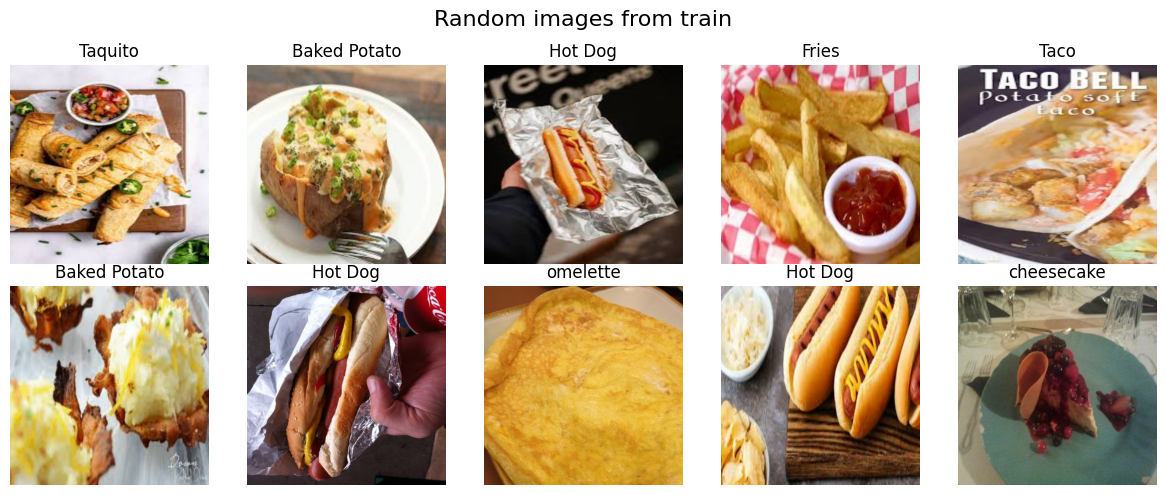

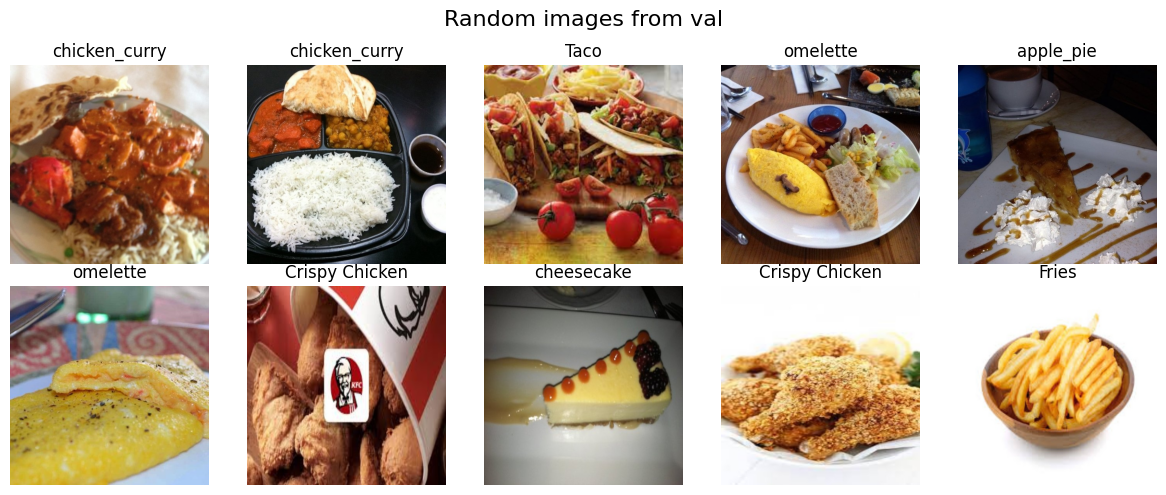

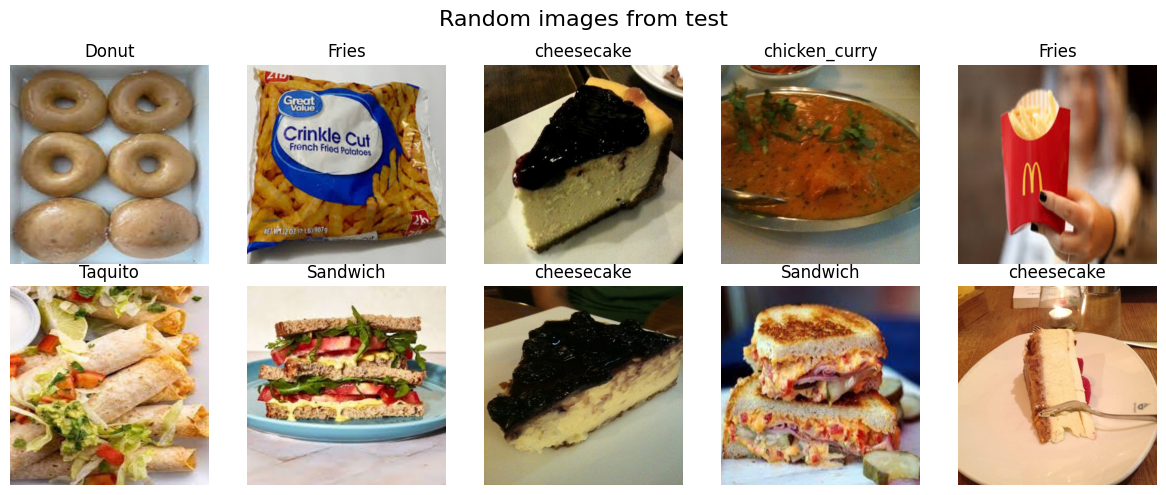

In [ ]:
display_random_images(df, "train")
display_random_images(df, "val")
display_random_images(df, "test")

# 4 - Preparazione del dataset e data augmentation

Andiamo ora a definire ed applicare alcune tecniche di **data augmentation** (che siano coerenti e plausibili per delle immagini contenenti dei cibi) per cercare di migliorare le performance dei modelli che utilizzeremo.

Ovviamente a tutti i dataset applicheremo le tecniche di base necessarie per portare le immagini nel formato e nella scala che la rete si aspetta come:
- Ridimensionamento.
- Normalizzazione.
- Padding.
- Conversione in tensore.

In più per il dataset di train definiamo anche altre trasformazioni come:
- Flip orizzontali/verticali (immagini speculari sull'asse x o y).
- Rotazioni (randomiche da -180 a 180 gradi).
- Variazioni di luminosità, contrasto e saturazione.

In [ ]:
train_transform = T.Compose([
  T.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),                        # Random resize
  T.RandomHorizontalFlip(),                                               # Random horizontal flip (default of  50% probability to be flipped)
  T.RandomVerticalFlip(),                                                 # Random vertical flip (default of 50% probability to be flipped)
  T.RandomRotation(degrees=180),                                          # Random rotation (between -180 degree and 180 degree)
  T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),  # Contrast, saturation and hue manipulation
  T.ToImage(),                                                            # Conversion to tensor
  T.ToDtype(torch.float32, scale=True),                                   # Normalization
  T.Normalize(mean=MEAN, std=STD)                                         # Normalization
])

In [ ]:
train_transform_no_aug = T.Compose([
  T.Resize(int(IMG_SIZE * 1.14)),       # Resize ~256: We make a slightly bigger than needed resize to be croped in the next transformation.
  T.CenterCrop(IMG_SIZE),               # Crop
  T.ToImage(),                          # Conversion to tensor
  T.ToDtype(torch.float32, scale=True), # Normalization
  T.Normalize(mean=MEAN, std=STD)       # Normalization
])

In [ ]:
val_transform = T.Compose([
  T.Resize(int(IMG_SIZE * 1.14)),       # Resize ~256: We make a slightly bigger than needed resize to be croped in the next transformation.
  T.CenterCrop(IMG_SIZE),               # Crop
  T.ToImage(),                          # Conversion to tensor
  T.ToDtype(torch.float32, scale=True), # Normalization
  T.Normalize(mean=MEAN, std=STD)       # Normalization
])

In [ ]:
test_transform = T.Compose([
  T.Resize(int(IMG_SIZE * 1.14)),       # Resize ~256: We make a slightly bigger than needed resize to be croped in the next transformation.
  T.CenterCrop(IMG_SIZE),               # Crop
  T.ToImage(),                          # Conversion to tensor
  T.ToDtype(torch.float32, scale=True), # Normalization
  T.Normalize(mean=MEAN, std=STD)       # Normalization
])

Ora creiamo i dataset con le trasformazioni e relativi `DataLoader`:

In [ ]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
train_dataset_no_aug = datasets.ImageFolder(TRAIN_DIR, transform=train_transform_no_aug)
val_dataset = datasets.ImageFolder(VAL_DIR, transform=val_transform)
test_dataset = datasets.ImageFolder(TEST_DIR, transform=test_transform)

print(f"Train images: {len(train_dataset)}")
print(f"Train (no aug) images: {len(train_dataset_no_aug)}")
print(f"Val images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")

Train images: 8960
Train (no aug) images: 8960
Val images: 2240
Test images: 2800


In [ ]:
train_loader = DataLoader(
  train_dataset,
  batch_size=BATCH_SIZE,
  shuffle=True,
  pin_memory=True if device.type == "cuda" else False, # It copies tensors into device/CUDA pinned memory before returning them
  drop_last=True # It rejects last batch if is not full
)

train_loader_no_aug = DataLoader(
  train_dataset_no_aug,
  batch_size=BATCH_SIZE,
  shuffle=True,
  pin_memory=True if device.type == "cuda" else False, # It copies tensors into device/CUDA pinned memory before returning them
  drop_last=True # It rejects last batch if is not full
)

val_loader = DataLoader(
  val_dataset,
  batch_size=BATCH_SIZE,
  shuffle=False, # We need val to be reproducible
  pin_memory=True if device.type == "cuda" else False # It copies tensors into device/CUDA pinned memory before returning them
)

test_loader = DataLoader(
  test_dataset,
  batch_size=BATCH_SIZE,
  shuffle=False, # We need test to be reproducible
  pin_memory=True if device.type == "cuda" else False # It copies tensors into device/CUDA pinned memory before returning them
)

Abbiamo creato anche un `DataLoader` di training semplice senza data augmentation che utilizzeremo per fare confronti tra gli stessi modelli ma con/senza data augmentation.

Per curiosità andiamo a verificare come appaiono ora alcune delle immagini che hanno subito delle trasformazioni:

In [ ]:
class_indexes = {idx: name for idx, name in enumerate(train_dataset.classes)} # Class name - class index mapping
class_indexes

{0: 'Baked Potato',
 1: 'Crispy Chicken',
 2: 'Donut',
 3: 'Fries',
 4: 'Hot Dog',
 5: 'Sandwich',
 6: 'Taco',
 7: 'Taquito',
 8: 'apple_pie',
 9: 'cheesecake',
 10: 'chicken_curry',
 11: 'ice_cream',
 12: 'omelette',
 13: 'sushi'}

In [ ]:
def show_batch(loader, title, n_images=5):
  """
  Show 15 images from the first batch of the loader.
  """

  images, labels = next(iter(loader))
  images = images[:n_images]
  labels = labels[:n_images]

  # Denormalization
  denormalization = T.Normalize(
    mean=[-m/s for m, s in zip(MEAN, STD)],
    std=[1/s for s in STD]
  )

  images_denormalized = denormalization(images).clamp(0, 1)

  fig, axes = plt.subplots(int(n_images/5), 5, figsize=(15, 8))
  axes = axes.flatten()

  for ax, img, lbl in zip(axes, images_denormalized, labels):

    img_np = img.permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title(f"{class_indexes[lbl.item()]}")
    ax.axis("off")

  fig.suptitle(title)
  plt.tight_layout()
  plt.show()

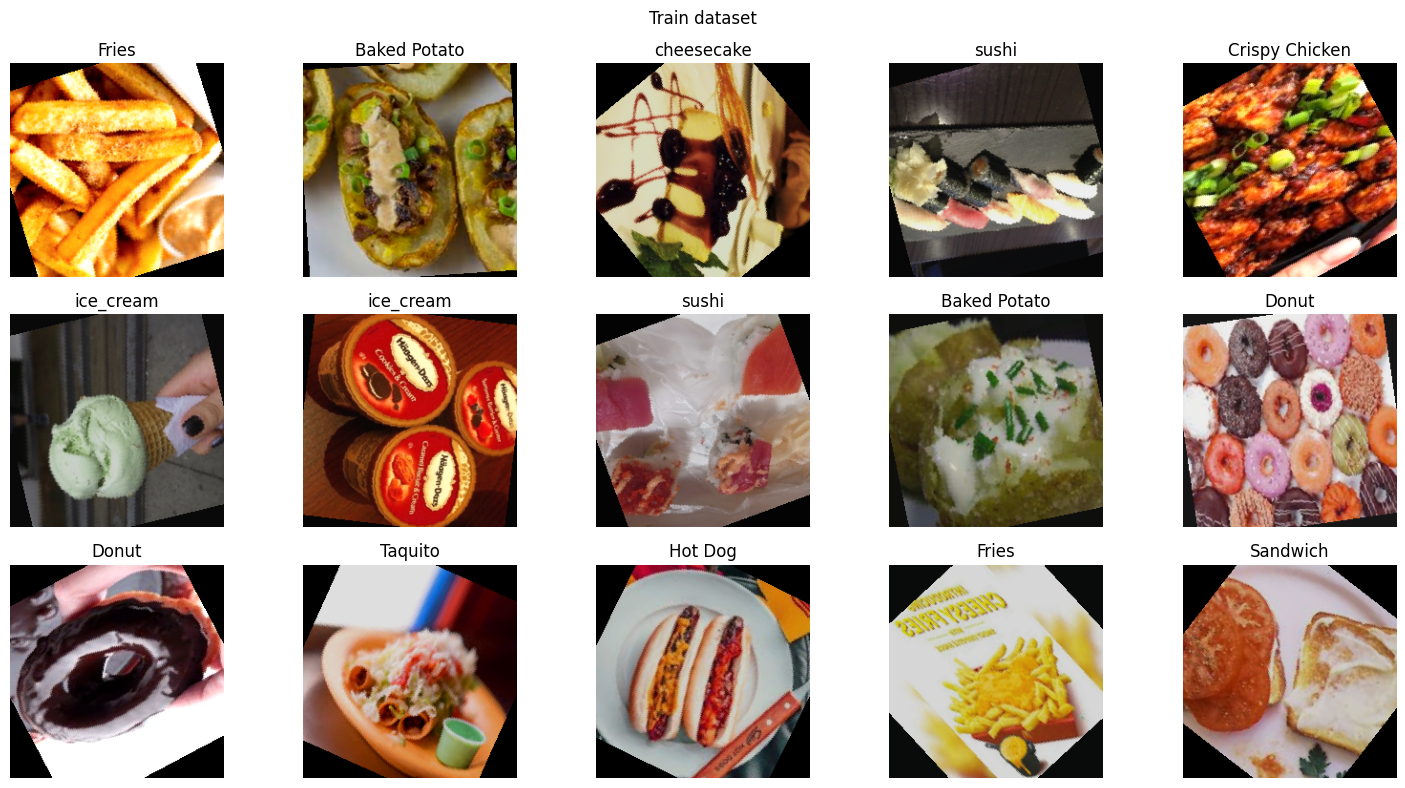

In [ ]:
show_batch(train_loader, "Train dataset", 15)

Vediamo effettivamente che nel dataset di train ci sono rotazioni, cropping, alterazioni di contrasto, saturazione etc etc...

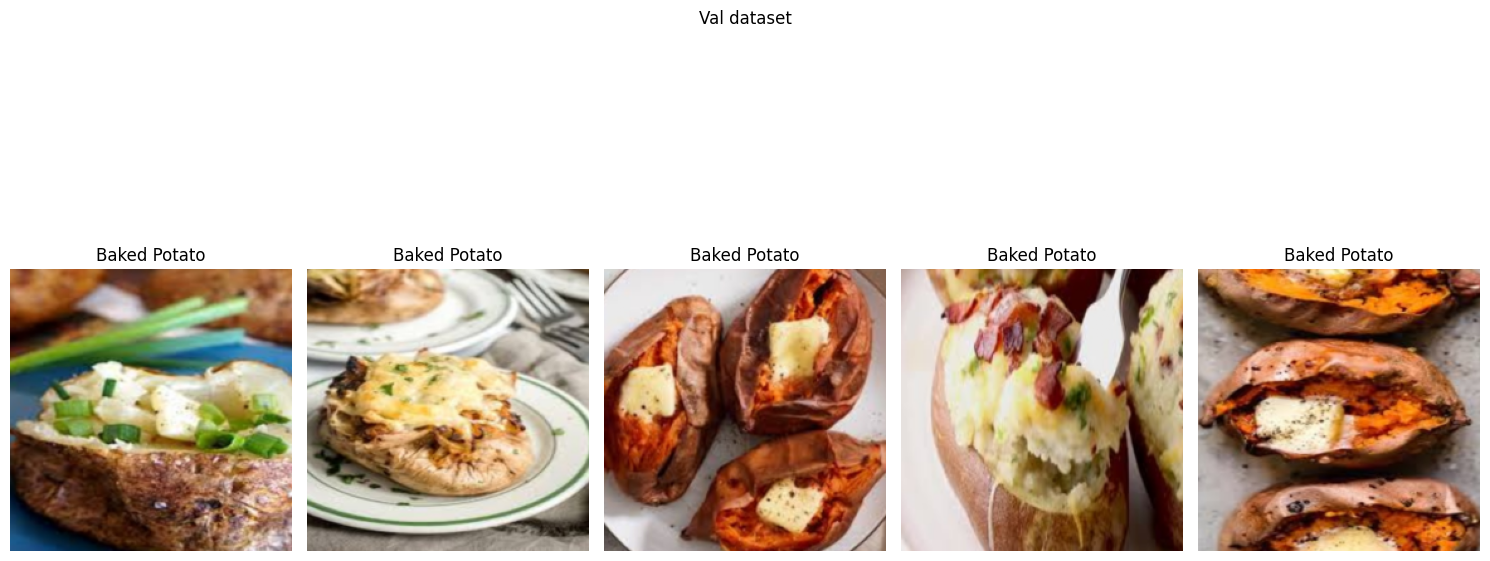

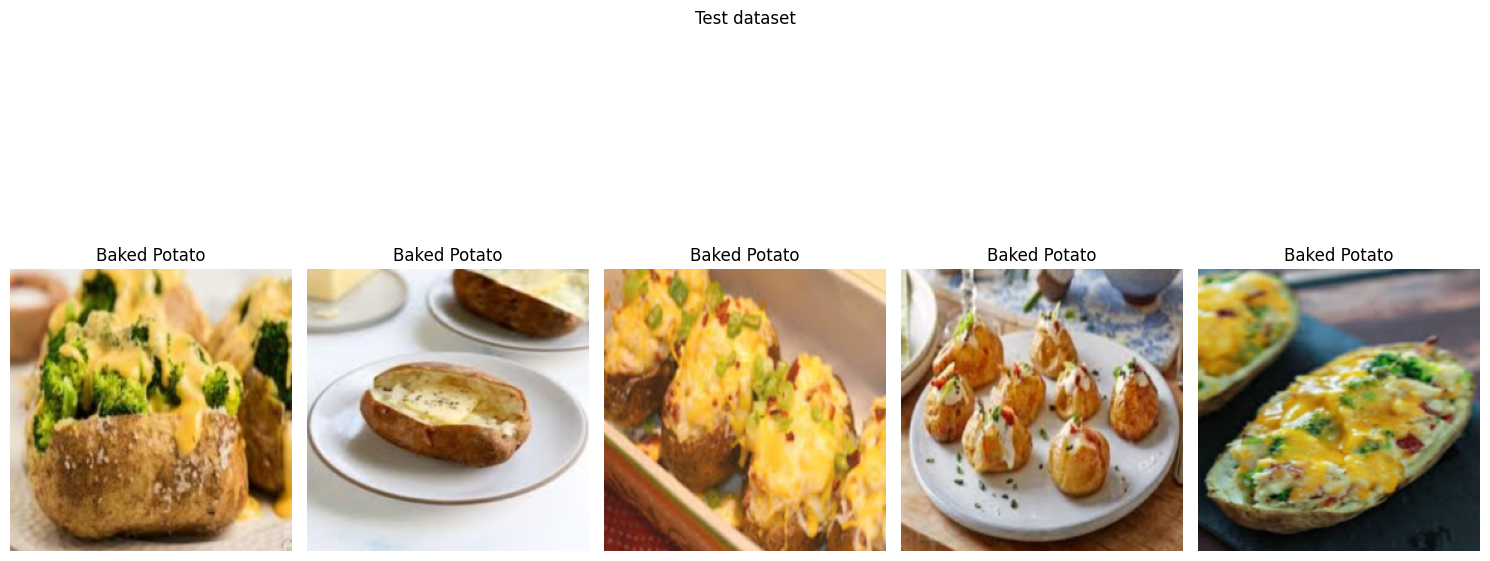

In [ ]:
show_batch(val_loader, "Val dataset",)
show_batch(test_loader, "Test dataset",)

Mentre nei dataset di val e test non ci sono questi tipi di manipolazioni.

# 5 - Definizione, addestramento e validazione dei modelli

## Definizione modelli

Ora passiamo alla definizione dei modelli che come accennato saranno 3:
- **Baseline**: modello con pesi casuali e non addestrato che farà da primo riferimento grossolano agli altri. Con 14 classi, una strategia casuale avrebbe un’accuracy attesa di circa il 7,14% se le classi fossero equiprobabili.
- **CNN semplice**: servirà a comprendere cosa si riesce ad ottenere con il training ma senza utilizzare i pesi pre-addestrati di VGG16 su ImageNet.
- **VGG16**: modello più avanzato con pesi pre-addestrati su ImageNet. Per VGG16 testeremo due configurazioni:
    1. **Backbone completamente congelato**: i layer convoluzionali pre-addestrati non verranno aggiornati e verrà addestrato principalmente il classificatore finale.
    2. **Fine-tuning di alcuni layer**: una parte iniziale del backbone resterà ugualmente congelato (vedremo quanto in base alle prestazione) mentre alcuni layer convoluzionali finali verranno sbloccati e addestrati.

Alcuni metodi helper:

In [ ]:
def count_model_parameters(model, trainable_only=False):
  """
  Count model's trainable or non-trainable parameters.
  """

  if trainable_only:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

  return sum(p.numel() for p in model.parameters())

In [ ]:
def print_model_summary(model, model_name="Model"):
  """
  Print model's summary.
  """

  total = count_model_parameters(model)
  trainable = count_model_parameters(model, trainable_only=True)

  print(model_name)
  print("------------------------------")
  print(f"Total parameters: {total:,}")
  print(f"Trainable parameters: {trainable:,}")
  print(f"Freezed parameters: {total - trainable:,}")

Baseline:

In [ ]:
class Baseline(nn.Module):
  """
  Baseline.

  Each block has:
    - Conv2d (filters 3x3 with 1 paddings)
    - BatchNorm2d
    - ReLU (non linearity)
    - MaxPool2d (stride 2)
  """

  def __init__(self, n_classes):

    super().__init__()

    self.features = nn.Sequential(
      # Input: [B, 3, 224, 224]
      nn.Conv2d(3, 32, kernel_size=3, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2),  # [B, 32, 112, 112]

      nn.Conv2d(32, 64, kernel_size=3, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2),  # [B, 64, 56, 56]

      nn.Conv2d(64, 128, kernel_size=3, padding=1),
      nn.BatchNorm2d(128),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2),  # [B, 128, 28, 28]

      nn.Conv2d(128, 256, kernel_size=3, padding=1),
      nn.BatchNorm2d(256),
      nn.ReLU(inplace=True),
      nn.MaxPool2d(kernel_size=2),  # [B, 256, 14, 14]

      nn.AdaptiveAvgPool2d((1, 1))  # [B, 256, 1, 1]
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Dropout(p=0.30),
      nn.Linear(256, 128),
      nn.ReLU(inplace=True),
      nn.Dropout(p=0.30),
      nn.Linear(128, n_classes)
    )

  def forward(self, x):

    x = self.features(x)

    return self.classifier(x)

In [ ]:
baseline_model = Baseline(N_CLASSES).to(device)

print_model_summary(baseline_model, "Baseline")
print()
print(baseline_model)

Baseline
------------------------------
Total parameters: 424,078
Trainable parameters: 424,078
Freezed parameters: 0

Baseline(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv

VGG16:

In [ ]:
def build_vgg16(n_classes, pretrained=True, freeze_features=True, dropout=0.30):
  """
  Build VGG16 replacing the last classifier.

  Args:
    n_classes: number of target classes.
    pretrained: if True, it loads pretrained weights.
    freeze_features: if True, it freezes the initial convolutional layers.
    dropout: dropout probability in the classifier.
  """

  weights = VGG16_Weights.IMAGENET1K_V1 if pretrained else None
  model = vgg16(weights=weights)

  if freeze_features:
    for param in model.features.parameters():
      param.requires_grad = False

  # Standard VGG16 classifier
  #   0. Linear
  #   1. ReLU
  #   2. Dropout
  #   3. Linear
  #   4. ReLU
  #   5. Dropout
  #   6. Linear

  model.classifier[2] = nn.Dropout(p=dropout)
  model.classifier[5] = nn.Dropout(p=dropout)

  # 6 - Final layer
  in_features = model.classifier[6].in_features # 4096
  model.classifier[6] = nn.Linear(in_features, n_classes)

  return model

In [ ]:
vgg16_frozen = build_vgg16(n_classes=N_CLASSES).to(device)

print_model_summary(vgg16_frozen, "VGG16 — Backbone freezed")
print()
print(vgg16_frozen.classifier)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:03<00:00, 178MB/s]


VGG16 — Backbone freezed
------------------------------
Total parameters: 134,317,902
Trainable parameters: 119,603,214
Freezed parameters: 14,714,688

Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.3, inplace=False)
  (6): Linear(in_features=4096, out_features=14, bias=True)
)


Vediamo come effettivamente rispetto ad una VGG16 standard:
- Il dropout dei layer 2/5 sia stato aggiornato a `0.3` (di default è `0.5`).
- L'ultimo layer ha come output `14`, ovvero il conto delle nostre classi.

## Addestramento e validazione dei modelli

Passiamo ora all'addestramento e validazione dei modelli:

**NOTA**: Di base il numero di epoche è inizializzato a 5 perché purtroppo già 5 epoche richiedono circa 20/25~ min di addestramento per modello (su GPU).

In [ ]:
def single_epoch_train(model, dataloader, loss_function, optimizer, device):
  """
  Single epoch model's training.
  """

  # For each batch:
  # 1. Move images and labels on current device
  # 2. Reset gradients
  # 3. Forward pass
  # 4. Compute loss
  # 5. Backward pass with gradient scaling
  # 6. Update model's weights
  # 7. Update aggregate loss and accuracy

  # Train mode
  model.train()

  # Metrics
  running_loss = 0.0
  running_correct = 0
  sample_count = 0

  # AMP - Automatic Mixed Precision
  use_amp = device.type == "cuda"
  scaler = torch.amp.GradScaler("cuda", enabled=use_amp)

  for images, labels in dataloader:

    images = images.to(device, non_blocking=True)
    labels = labels.to(device, non_blocking=True)

    optimizer.zero_grad(set_to_none=True) # Reset gradients

    with torch.amp.autocast(device_type=device.type, dtype=torch.float16, enabled=use_amp):
      logits = model(images) # Forward pass
      loss = loss_function(logits, labels)

    scaler.scale(loss).backward() # Backward pass
    scaler.step(optimizer)
    scaler.update()

    batch_size = labels.size(0)
    running_loss += loss.item() * batch_size
    running_correct += (logits.argmax(dim=1) == labels).sum().item()
    sample_count += batch_size

  return {
    "loss": running_loss / sample_count,
    "accuracy": running_correct / sample_count,
  }

In [ ]:
def evaluate(model, dataloader, loss_function, device):
  """
  Evaluate the model.
  """

  # For each batch:
  # 1. Move images and labels on current device
  # 2. Forward pass
  # 3. Compute loss
  # 4. Update aggregate loss and accuracy

  # Eval mode
  model.eval()

  # Metrics
  running_loss = 0.0
  running_correct = 0
  sample_count = 0

  with torch.inference_mode():
    for images, labels in dataloader:

      images = images.to(device, non_blocking=True)
      labels = labels.to(device, non_blocking=True)

      logits = model(images)
      loss = loss_function(logits, labels)

      batch_size = labels.size(0)
      running_loss += loss.item() * batch_size
      running_correct += (logits.argmax(dim=1) == labels).sum().item()
      sample_count += batch_size

  return {
    "loss": running_loss / sample_count,
    "accuracy": running_correct / sample_count,
  }

In [ ]:
def load_checkpoint_file(path, map_location="cpu"):
  """
  Load a checkpoint file.
  """

  return torch.load(path, map_location=map_location, weights_only=False)

In [ ]:
def empty_cuda_cache():
  """
  Empty cuda cache.
  """

  if torch.cuda.is_available():
    torch.cuda.empty_cache()

L'addestramento:
- Salva come checkpoint i modelli migliori (in base alla val loss) e ripristina il migliore alla fine.
- Prevede l'early stopping nel caso in cui non ci sono miglioramenti.

In [ ]:
def fit(
  model,
  train_loader,
  val_loader,
  loss_function,
  optimizer,
  device,
  experiment_name,
  config,
  num_epochs=N_EPOCHS,
  patience=PATIENCE,
  scheduler=None,
  min_delta=0.0
):
  """
  Fit the model.
  """

  # For each epoch:
  # 1. Compute tran metrics.
  # 2. Compute val metrics.
  # 3. Update model's history.
  # 4. Check early stopping.
  # 5. Check scheduler.

  checkpoint_path = os.path.join(CHECKPOINT_DIR, f"{experiment_name}.pth")
  history_path = os.path.join(HISTORY_DIR, f"{experiment_name}.json")

  history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
  }

  best_val_loss = float("inf")
  best_epoch = 0
  epochs_without_improvement = 0

  total_params = count_model_parameters(model)
  trainable_params = count_model_parameters(model, True)

  for epoch in range(1, num_epochs + 1):

    train_metrics = single_epoch_train(model, train_loader, loss_function, optimizer, device)
    val_metrics = evaluate(model, val_loader, loss_function, device)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_metrics["loss"])
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["learning_rate"].append(current_lr)

    print(
      f"[{experiment_name}] "
      f"Epoch {epoch:02d}/{num_epochs} | "
      f"train loss {train_metrics['loss']:.4f} | "
      f"train acc {train_metrics['accuracy']:.4f} | "
      f"val loss {val_metrics['loss']:.4f} | "
      f"val acc {val_metrics['accuracy']:.4f} | "
      f"lr {current_lr:.2e}"
    )

    improved = val_metrics["loss"] < (best_val_loss - min_delta)

    # Early stopping
    if improved:
      # 1 - We had an improvement so we can save the best checkpoint
      best_val_loss = val_metrics["loss"]
      best_epoch = epoch
      epochs_without_improvement = 0

      torch.save(
        {
          "experiment_name": experiment_name,
          "epoch": epoch,
          "model_state_dict": model.state_dict(),
          "optimizer_state_dict": optimizer.state_dict(),
          "val_loss": val_metrics["loss"],
          "val_accuracy": val_metrics["accuracy"],
          "history": deepcopy(history),
          "config": config,
        },
        checkpoint_path,
      )
    else:
      # 1 - We had no improvement so we have to update the counter
      epochs_without_improvement += 1

    if scheduler is not None:
      if isinstance(scheduler, ReduceLROnPlateau):
        scheduler.step(val_metrics["loss"])
      else:
        scheduler.step()

    if epochs_without_improvement >= patience:
      print(f"Early stopping at epoch:{epoch}.")
      break

  best_checkpoint = load_checkpoint_file(checkpoint_path, map_location=device)
  model.load_state_dict(best_checkpoint["model_state_dict"])

  with open(history_path, "w", encoding="utf-8") as file:
    json.dump(history, file, indent=2)

  summary = {
    "experiment": experiment_name,
    "architecture": config["architecture"],
    "augmentation": config["augmentation"],
    "training_mode": config["training_mode"],
    "total_params": total_params,
    "trainable_params": trainable_params,
    "epochs_run": len(history["train_loss"]),
    "best_epoch": best_checkpoint["epoch"],
    "best_val_loss": best_checkpoint["val_loss"],
    "best_val_accuracy": best_checkpoint["val_accuracy"],
    "checkpoint": str(checkpoint_path)
  }

  return model, history, summary

In [ ]:
def plot_history(history, title):
  """
  Plot the training history.
  """

  epochs = range(1, len(history["train_loss"]) + 1)

  fig, axes = plt.subplots(1, 2, figsize=(13, 4))

  axes[0].plot(epochs, history["train_loss"], label="Train")
  axes[0].plot(epochs, history["val_loss"], label="Validation")
  axes[0].set_title(f"{title} - Loss")
  axes[0].set_xlabel("Epoch")
  axes[0].set_ylabel("Loss")
  axes[0].legend()
  axes[0].grid(alpha=0.3)

  axes[1].plot(epochs, history["train_accuracy"], label="Train")
  axes[1].plot(epochs, history["val_accuracy"], label="Validation")
  axes[1].set_title(f"{title} - Accuracy")
  axes[1].set_xlabel("Epoch")
  axes[1].set_ylabel("Accuracy")
  axes[1].legend()
  axes[1].grid(alpha=0.3)

  plt.tight_layout()
  plt.show()

In [ ]:
experiment_results = []
model_registry = {}

def register_experiment(summary, model_info):
  """
  Register model's experiment.
  """

  global experiment_results

  experiment_results = [
    row for row in experiment_results
    if row["experiment"] != summary["experiment"] # No duplicates
  ]

  experiment_results.append(summary)
  model_registry[summary["experiment"]] = model_info

  pd.DataFrame(experiment_results).to_csv(os.path.join(RESULTS_DIR, "validation_results.csv"), index=False)

  with open(os.path.join(RESULTS_DIR, "model_registry.json"), "w", encoding="utf-8") as file:
    json.dump(model_registry, file, indent=2)

**Primo test**: Baseline senza augmentation e pesi casuali.

[model_1_baseline_no_aug] Epoch 01/5 | train loss 2.2409 | train acc 0.2289 | val loss 2.0959 | val acc 0.2603 | lr 1.00e-03
[model_1_baseline_no_aug] Epoch 02/5 | train loss 1.9628 | train acc 0.3046 | val loss 1.9192 | val acc 0.3299 | lr 1.00e-03
[model_1_baseline_no_aug] Epoch 03/5 | train loss 1.8410 | train acc 0.3538 | val loss 1.7028 | val acc 0.4036 | lr 1.00e-03
[model_1_baseline_no_aug] Epoch 04/5 | train loss 1.7390 | train acc 0.3814 | val loss 1.8318 | val acc 0.3853 | lr 1.00e-03
[model_1_baseline_no_aug] Epoch 05/5 | train loss 1.6607 | train acc 0.4202 | val loss 1.6702 | val acc 0.4348 | lr 1.00e-03


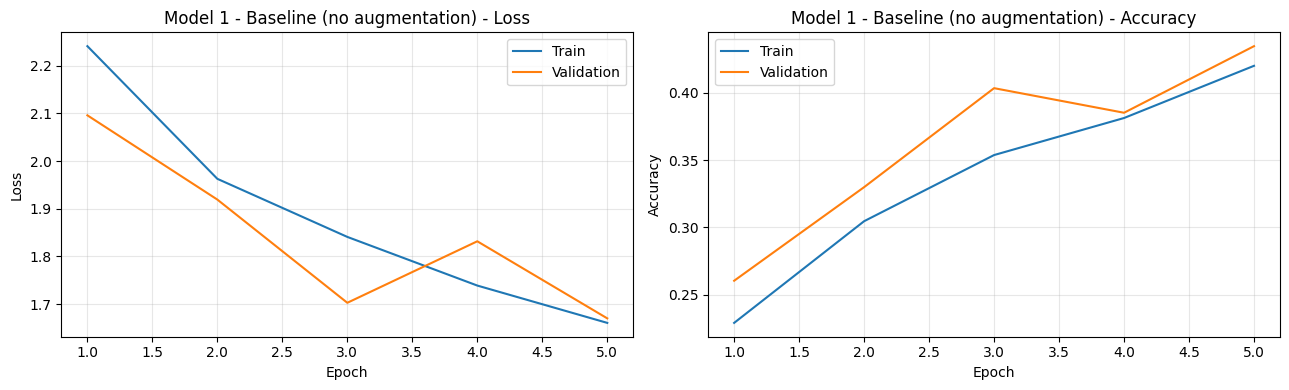

{'experiment': 'model_1_baseline_no_aug',
 'architecture': 'Baseline',
 'augmentation': False,
 'training_mode': 'from_scratch',
 'total_params': 424078,
 'trainable_params': 424078,
 'epochs_run': 5,
 'best_epoch': 5,
 'best_val_loss': 1.670180320739746,
 'best_val_accuracy': 0.4348214285714286,
 'checkpoint': './content/checkpoints/model_1_baseline_no_aug.pth'}

In [ ]:
model_1 = Baseline(N_CLASSES).to(device)

optimizer_1 = AdamW(
  model_1.parameters(),
  lr=1e-3,
  weight_decay=1e-4
)

scheduler_1 = ReduceLROnPlateau(
  optimizer_1,
  mode="min",
  factor=0.5,
  patience=2
)

config_1 = {
  "architecture": "Baseline",
  "augmentation": False,
  "training_mode": "from_scratch",
  "learning_rate": 1e-3,
  "weight_decay": 1e-4
}

model_1, history_1, summary_1 = fit(
  model=model_1,
  train_loader=train_loader_no_aug,
  val_loader=val_loader,
  loss_function=nn.CrossEntropyLoss(),
  optimizer=optimizer_1,
  device=device,
  experiment_name="model_1_baseline_no_aug",
  config=config_1,
  num_epochs=N_EPOCHS,
  patience=PATIENCE,
  scheduler=scheduler_1
)

register_experiment(
  summary_1,
  {
    "family": "baseline_no_aug",
    "mode": "from_scratch",
    "checkpoint": summary_1["checkpoint"],
    "augmentation": False
  }
)

plot_history(history_1, "Model 1 - Baseline (no augmentation)")
summary_1

In [ ]:
del model_1, optimizer_1, scheduler_1
gc.collect()

empty_cuda_cache()

**Secondo test**: Baseline con augmentation e pesi casuali.

Partiamo dal modello precedente ma cambiamo loader ed utilizziamo quello con data augmentation.

[model_2_baseline_aug] Epoch 01/5 | train loss 2.4235 | train acc 0.1770 | val loss 2.2748 | val acc 0.2241 | lr 1.00e-03
[model_2_baseline_aug] Epoch 02/5 | train loss 2.2634 | train acc 0.2230 | val loss 2.0785 | val acc 0.3000 | lr 1.00e-03
[model_2_baseline_aug] Epoch 03/5 | train loss 2.1776 | train acc 0.2584 | val loss 2.2868 | val acc 0.2321 | lr 1.00e-03
[model_2_baseline_aug] Epoch 04/5 | train loss 2.0974 | train acc 0.2827 | val loss 2.2858 | val acc 0.2451 | lr 1.00e-03
[model_2_baseline_aug] Epoch 05/5 | train loss 2.0495 | train acc 0.2969 | val loss 2.0574 | val acc 0.2844 | lr 1.00e-03


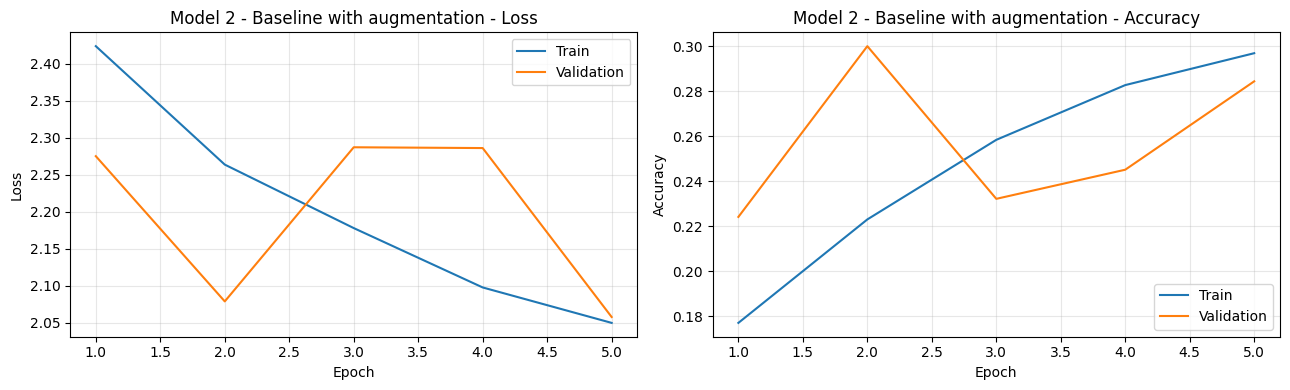

{'experiment': 'model_2_baseline_aug',
 'architecture': 'Baseline',
 'augmentation': True,
 'training_mode': 'from_scratch',
 'total_params': 424078,
 'trainable_params': 424078,
 'epochs_run': 5,
 'best_epoch': 5,
 'best_val_loss': 2.057430454662868,
 'best_val_accuracy': 0.284375,
 'checkpoint': './content/checkpoints/model_2_baseline_aug.pth'}

In [ ]:
model_2 = Baseline(N_CLASSES).to(device)

optimizer_2 = AdamW(
  model_2.parameters(),
  lr=1e-3,
  weight_decay=1e-4
)

scheduler_2 = ReduceLROnPlateau(
  optimizer_2,
  mode="min",
  factor=0.5,
  patience=2
)

config_2 = {
  "architecture": "Baseline",
  "augmentation": True,
  "training_mode": "from_scratch",
  "learning_rate": 1e-3,
  "weight_decay": 1e-4
}

model_2, history_2, summary_2 = fit(
  model=model_2,
  train_loader=train_loader,
  val_loader=val_loader,
  loss_function=nn.CrossEntropyLoss(),
  optimizer=optimizer_2,
  device=device,
  experiment_name="model_2_baseline_aug",
  config=config_2,
  num_epochs=N_EPOCHS,
  patience=PATIENCE,
  scheduler=scheduler_2
)

register_experiment(
  summary_2,
  {
    "family": "baseline_aug",
    "mode": "from_scratch",
    "checkpoint": summary_2["checkpoint"],
    "augmentation": True
  }
)

plot_history(history_2, "Model 2 - Baseline with augmentation")
summary_2

In [ ]:
del model_2, optimizer_2, scheduler_2
gc.collect()

empty_cuda_cache()

Eseguiamo un confronto tra i due modelli baseline con e senza data augmentation:

In [ ]:
pd.DataFrame(experiment_results).sort_values(
  "best_val_accuracy",
  ascending=False
).reset_index(drop=True)

,experiment,architecture,augmentation,training_mode,total_params,trainable_params,epochs_run,best_epoch,best_val_loss,best_val_accuracy,checkpoint
0,model_1_baseline_no_aug,Baseline,False,from_scratch,424078,424078,5,5,1.67018,0.434821,./content/checkpoints/model_1_baseline_no_aug.pth
1,model_2_baseline_aug,Baseline,True,from_scratch,424078,424078,5,5,2.05743,0.284375,./content/checkpoints/model_2_baseline_aug.pth


Vediamo come in realtà il modello baseline con data augmentation abbia performato peggio.

**Terzo test**: VGG16 freezed senza augmentation (backbone congelato).

Totals: 134,317,902 | Trainable: 119,603,214
[model_3_vgg16_frozen_no_aug] Epoch 01/5 | train loss 1.2163 | train acc 0.6266 | val loss 0.8349 | val acc 0.7402 | lr 1.00e-03
[model_3_vgg16_frozen_no_aug] Epoch 02/5 | train loss 0.6040 | train acc 0.8305 | val loss 0.9911 | val acc 0.7353 | lr 1.00e-03
[model_3_vgg16_frozen_no_aug] Epoch 03/5 | train loss 0.4665 | train acc 0.8853 | val loss 1.5307 | val acc 0.6848 | lr 1.00e-03
[model_3_vgg16_frozen_no_aug] Epoch 04/5 | train loss 0.4036 | train acc 0.9065 | val loss 1.5108 | val acc 0.7094 | lr 1.00e-03
Early stopping at epoch:4.


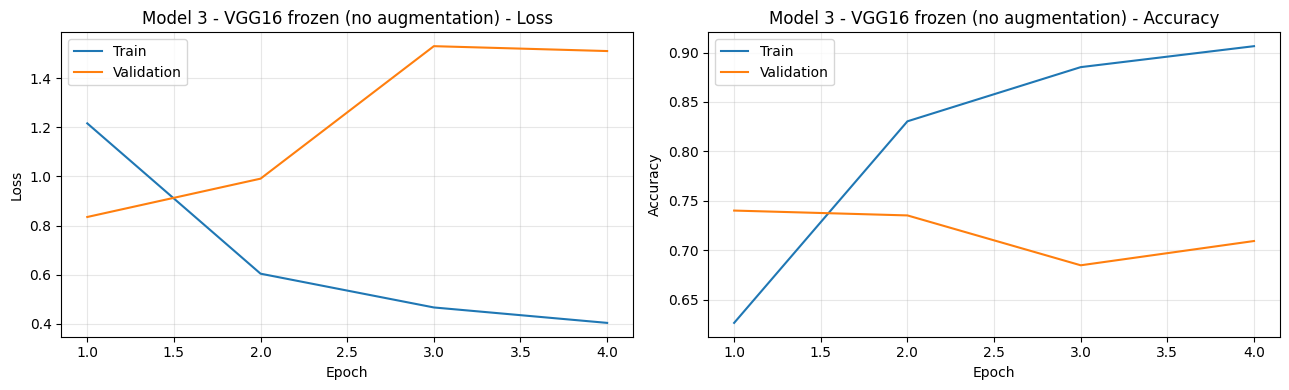

{'experiment': 'model_3_vgg16_frozen_no_aug',
 'architecture': 'VGG16',
 'augmentation': False,
 'training_mode': 'frozen_backbone',
 'total_params': 134317902,
 'trainable_params': 119603214,
 'epochs_run': 4,
 'best_epoch': 1,
 'best_val_loss': 0.834945859014988,
 'best_val_accuracy': 0.7401785714285715,
 'checkpoint': './content/checkpoints/model_3_vgg16_frozen_no_aug.pth'}

In [ ]:
model_3 = build_vgg16(n_classes=N_CLASSES).to(device)

print(f"Totals: {count_model_parameters(model_3):,} | Trainable: {count_model_parameters(model_3, trainable_only=True):,}")

optimizer_3 = AdamW(
  (p for p in model_3.parameters() if p.requires_grad),
  lr=1e-3,
  weight_decay=1e-4
)

scheduler_3 = ReduceLROnPlateau(
  optimizer_3,
  mode="min",
  factor=0.5,
  patience=2
)

config_3 = {
  "architecture": "VGG16",
  "augmentation": False,
  "training_mode": "frozen_backbone",
  "pretrained": True,
  "learning_rate": 1e-3,
  "weight_decay": 1e-4,
}

model_3, history_3, summary_3 = fit(
  model=model_3,
  train_loader=train_loader_no_aug,
  val_loader=val_loader,
  loss_function=nn.CrossEntropyLoss(),
  optimizer=optimizer_3,
  device=device,
  experiment_name="model_3_vgg16_frozen_no_aug",
  config=config_3,
  num_epochs=N_EPOCHS,
  patience=PATIENCE,
  scheduler=scheduler_3
)

register_experiment(
  summary_3,
  {
    "family": "vgg16",
    "mode": "frozen",
    "checkpoint": summary_3["checkpoint"],
    "augmentation": False
  }
)

plot_history(history_3, "Model 3 - VGG16 frozen (no augmentation)")
summary_3

In [ ]:
del model_3, optimizer_3, scheduler_3
gc.collect()

empty_cuda_cache()

**Quarto test**: VGG16 freezed con augmentation (backbone è congelato).

Pertanto anche qua come già fatto prima partiamo dal modello precedente ma cambiamo loader ed utilizziamo quello con data augmentation.

[model_4_vgg16_frozen_aug] Epoch 01/5 | train loss 1.9025 | train acc 0.3977 | val loss 1.0805 | val acc 0.6491 | lr 1.00e-03
[model_4_vgg16_frozen_aug] Epoch 02/5 | train loss 1.5263 | train acc 0.5188 | val loss 1.1450 | val acc 0.6268 | lr 1.00e-03
[model_4_vgg16_frozen_aug] Epoch 03/5 | train loss 1.4148 | train acc 0.5512 | val loss 0.9617 | val acc 0.6911 | lr 1.00e-03
[model_4_vgg16_frozen_aug] Epoch 04/5 | train loss 1.3552 | train acc 0.5761 | val loss 0.9191 | val acc 0.7259 | lr 1.00e-03
[model_4_vgg16_frozen_aug] Epoch 05/5 | train loss 1.3129 | train acc 0.5867 | val loss 1.0373 | val acc 0.6741 | lr 1.00e-03


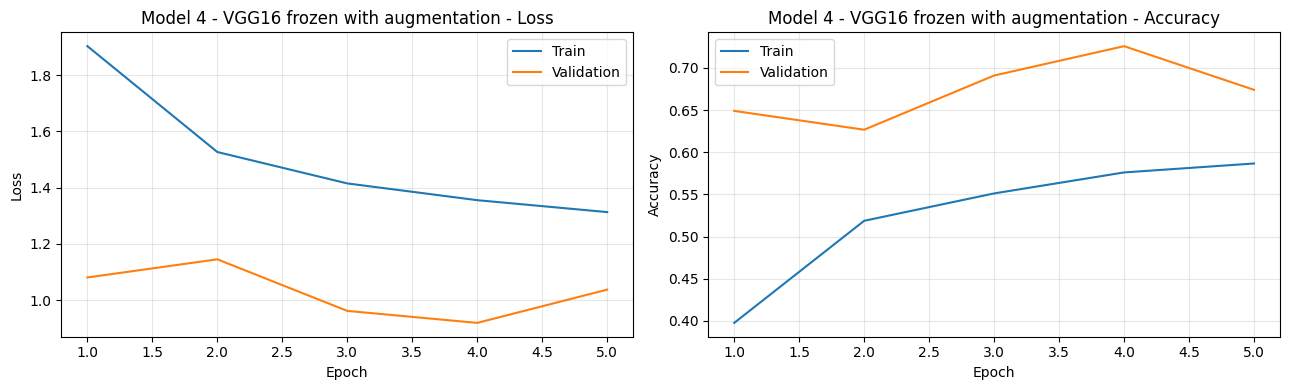

{'experiment': 'model_4_vgg16_frozen_aug',
 'architecture': 'VGG16',
 'augmentation': True,
 'training_mode': 'frozen_backbone',
 'total_params': 134317902,
 'trainable_params': 119603214,
 'epochs_run': 5,
 'best_epoch': 4,
 'best_val_loss': 0.91912294285638,
 'best_val_accuracy': 0.7258928571428571,
 'checkpoint': './content/checkpoints/model_4_vgg16_frozen_aug.pth'}

In [ ]:
model_4 = build_vgg16(n_classes=N_CLASSES).to(device)

optimizer_4 = AdamW(
  (p for p in model_4.parameters() if p.requires_grad),
  lr=1e-3,
  weight_decay=1e-4
)

scheduler_4 = ReduceLROnPlateau(
  optimizer_4,
  mode="min",
  factor=0.5,
  patience=2
)

config_4 = {
  "architecture": "VGG16",
  "augmentation": True,
  "training_mode": "frozen_backbone",
  "pretrained": True,
  "learning_rate": 1e-3,
  "weight_decay": 1e-4,
}

model_4, history_4, summary_4 = fit(
  model=model_4,
  train_loader=train_loader,
  val_loader=val_loader,
  loss_function=nn.CrossEntropyLoss(),
  optimizer=optimizer_4,
  device=device,
  experiment_name="model_4_vgg16_frozen_aug",
  config=config_4,
  num_epochs=N_EPOCHS,
  patience=PATIENCE,
  scheduler=scheduler_4
)

register_experiment(
  summary_4,
  {
    "family": "vgg16",
    "mode": "frozen",
    "checkpoint": summary_4["checkpoint"],
    "augmentation": True
  }
)

plot_history(history_4, "Model 4 - VGG16 frozen with augmentation")
summary_4

In [ ]:
del model_4, optimizer_4, scheduler_4
gc.collect()

empty_cuda_cache()

Eseguiamo un confronto tra i due modelli VGG16, quindi pre-trained e backbone congelato, con e senza data augmentation:

In [ ]:
results_before_finetuning = pd.DataFrame(experiment_results).sort_values(
  "best_val_accuracy",
  ascending=False
).reset_index(drop=True)

results_before_finetuning

,experiment,architecture,augmentation,training_mode,total_params,trainable_params,epochs_run,best_epoch,best_val_loss,best_val_accuracy,checkpoint
0,model_3_vgg16_frozen_no_aug,VGG16,False,frozen_backbone,134317902,119603214,4,1,0.834946,0.740179,./content/checkpoints/model_3_vgg16_frozen_no_...
1,model_4_vgg16_frozen_aug,VGG16,True,frozen_backbone,134317902,119603214,5,4,0.919123,0.725893,./content/checkpoints/model_4_vgg16_frozen_aug...
2,model_1_baseline_no_aug,Baseline,False,from_scratch,424078,424078,5,5,1.670180,0.434821,./content/checkpoints/model_1_baseline_no_aug.pth
3,model_2_baseline_aug,Baseline,True,from_scratch,424078,424078,5,5,2.057430,0.284375,./content/checkpoints/model_2_baseline_aug.pth


Le performance sono nettamente migliorate sfruttando un modello pre-trained come VGG16. Ancora una volta la data augmentation non ha portato vantaggi.

**Quinto test**: VGG16 fine-tuned senza augmentation.

Carichiamo il miglior modello VGG16 freezed senza augmentation (terzo test) tra i checkpoints disponibili e questa volta sblocchiamo l'ultimo blocco convoluzionale.

In [ ]:
def unfreeze_model_layers(model, start_index=24):
  """
  Unfreeze last model's layers.
  """

  for param in model.features.parameters():
      param.requires_grad = False

  for layer in model.features[start_index:]:
      for param in layer.parameters():
          param.requires_grad = True

  for param in model.classifier.parameters():
      param.requires_grad = False

  for param in model.classifier[6].parameters():
      param.requires_grad = True

  return model

In [ ]:
model_5 = build_vgg16(n_classes=N_CLASSES, pretrained=False)

checkpoint_3 = load_checkpoint_file(model_registry["model_3_vgg16_frozen_no_aug"]["checkpoint"])

model_5.load_state_dict(checkpoint_3["model_state_dict"])
model_5 = unfreeze_model_layers(model_5)
model_5 = model_5.to(device)

print(f"Totals: {count_model_parameters(model_5):,} | Trainable: {count_model_parameters(model_5, trainable_only=True):,}")

Totals: 134,317,902 | Trainable: 7,136,782


[model_5_vgg16_finetuned_no_aug] Epoch 01/5 | train loss 0.3309 | train acc 0.8929 | val loss 0.6993 | val acc 0.7821 | lr 1.00e-05
[model_5_vgg16_finetuned_no_aug] Epoch 02/5 | train loss 0.2401 | train acc 0.9233 | val loss 0.6810 | val acc 0.7933 | lr 1.00e-05
[model_5_vgg16_finetuned_no_aug] Epoch 03/5 | train loss 0.1900 | train acc 0.9388 | val loss 0.6923 | val acc 0.7920 | lr 1.00e-05
[model_5_vgg16_finetuned_no_aug] Epoch 04/5 | train loss 0.1562 | train acc 0.9482 | val loss 0.6978 | val acc 0.7996 | lr 1.00e-05
[model_5_vgg16_finetuned_no_aug] Epoch 05/5 | train loss 0.1193 | train acc 0.9617 | val loss 0.6936 | val acc 0.8004 | lr 1.00e-05
Early stopping at epoch:5.


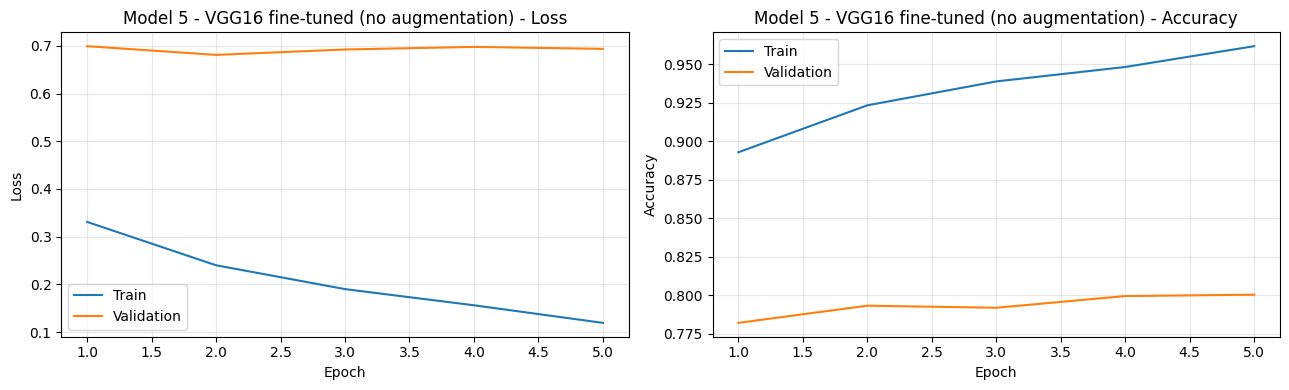

{'experiment': 'model_5_vgg16_finetuned_no_aug',
 'architecture': 'VGG16',
 'augmentation': False,
 'training_mode': 'fine_tune_last_block',
 'total_params': 134317902,
 'trainable_params': 7136782,
 'epochs_run': 5,
 'best_epoch': 2,
 'best_val_loss': 0.6809814414807729,
 'best_val_accuracy': 0.7933035714285714,
 'checkpoint': './content/checkpoints/model_5_vgg16_finetuned_no_aug.pth'}

In [ ]:
optimizer_5 = AdamW(
  [
    {
      "params": [
        p for p in model_5.features[24:].parameters()
        if p.requires_grad
      ],
      "lr": 1e-5
    },
    {
      "params": model_5.classifier[6].parameters(),
      "lr": 1e-4
    }
  ],
  weight_decay=1e-4
)

scheduler_5 = ReduceLROnPlateau(
  optimizer_5,
  mode="min",
  factor=0.5,
  patience=2
)

config_5 = {
  "architecture": "VGG16",
  "augmentation": False,
  "training_mode": "fine_tune_last_block",
  "source_checkpoint": model_registry["model_3_vgg16_frozen_no_aug"]["checkpoint"],
  "feature_learning_rate": 1e-5,
  "head_learning_rate": 1e-4,
  "weight_decay": 1e-4,
  "unfreeze_start_index": 24
}

model_5, history_5, summary_5 = fit(
  model=model_5,
  train_loader=train_loader_no_aug,
  val_loader=val_loader,
  loss_function=nn.CrossEntropyLoss(),
  optimizer=optimizer_5,
  device=device,
  experiment_name="model_5_vgg16_finetuned_no_aug",
  config=config_5,
  num_epochs=N_EPOCHS,
  patience=PATIENCE,
  scheduler=scheduler_5
)

register_experiment(
  summary_5,
  {
    "family": "vgg16",
    "mode": "fine_tuned_last_block",
    "checkpoint": summary_5["checkpoint"],
    "augmentation": False,
    "unfreeze_start_index": 24
  }
)

plot_history(history_5, "Model 5 - VGG16 fine-tuned (no augmentation)")
summary_5

In [ ]:
del model_5, optimizer_5, scheduler_5, checkpoint_3
gc.collect()

empty_cuda_cache()

**Sesto test**: VGG16 fine-tuned con augmentation.

Anche qui partiamo dal miglior modello del quarto test ed utilizziamo il loader con data augmentation.

In [ ]:
model_6 = build_vgg16(n_classes=N_CLASSES, pretrained=False)

checkpoint_4 = load_checkpoint_file(model_registry["model_4_vgg16_frozen_aug"]["checkpoint"])

model_6.load_state_dict(checkpoint_4["model_state_dict"])
model_6 = unfreeze_model_layers(model_6)
model_6 = model_6.to(device)

print(f"Totals: {count_model_parameters(model_6):,} | Trainable: {count_model_parameters(model_6, trainable_only=True):,}")

Totals: 134,317,902 | Trainable: 7,136,782


[model_6_vgg16_finetuned_aug] Epoch 01/5 | train loss 1.1314 | train acc 0.6385 | val loss 0.8359 | val acc 0.7455 | lr 1.00e-05
[model_6_vgg16_finetuned_aug] Epoch 02/5 | train loss 1.0545 | train acc 0.6676 | val loss 0.8023 | val acc 0.7513 | lr 1.00e-05
[model_6_vgg16_finetuned_aug] Epoch 03/5 | train loss 0.9877 | train acc 0.6885 | val loss 0.7986 | val acc 0.7513 | lr 1.00e-05
[model_6_vgg16_finetuned_aug] Epoch 04/5 | train loss 0.9617 | train acc 0.6954 | val loss 0.8004 | val acc 0.7469 | lr 1.00e-05
[model_6_vgg16_finetuned_aug] Epoch 05/5 | train loss 0.9007 | train acc 0.7138 | val loss 0.7491 | val acc 0.7710 | lr 1.00e-05


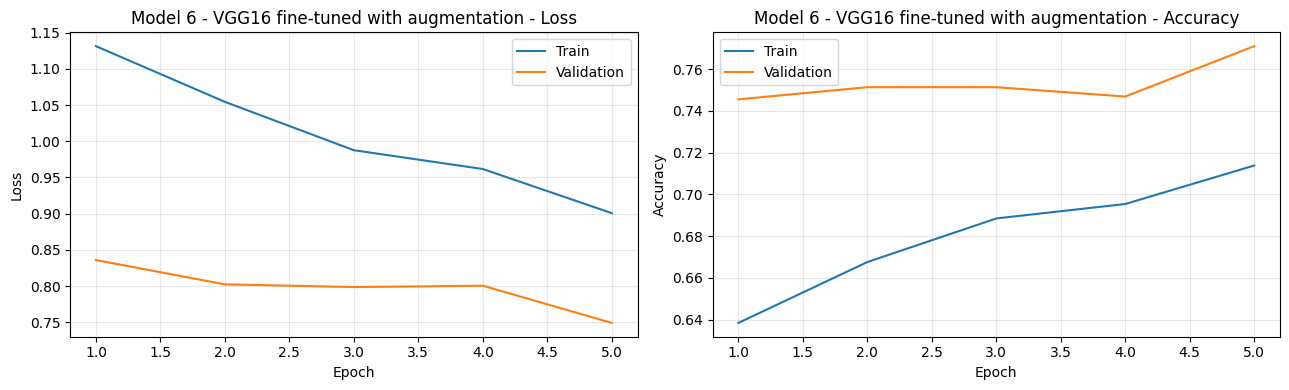

{'experiment': 'model_6_vgg16_finetuned_aug',
 'architecture': 'VGG16',
 'augmentation': True,
 'training_mode': 'fine_tune_last_block',
 'total_params': 134317902,
 'trainable_params': 7136782,
 'epochs_run': 5,
 'best_epoch': 5,
 'best_val_loss': 0.7490869530609676,
 'best_val_accuracy': 0.7709821428571428,
 'checkpoint': './content/checkpoints/model_6_vgg16_finetuned_aug.pth'}

In [ ]:
optimizer_6 = AdamW(
  [
    {
      "params": [
        p for p in model_6.features[24:].parameters()
        if p.requires_grad
      ],
      "lr": 1e-5
    },
    {
      "params": model_6.classifier[6].parameters(),
      "lr": 1e-4
    }
  ],
  weight_decay=1e-4
)

scheduler_6 = ReduceLROnPlateau(
  optimizer_6,
  mode="min",
  factor=0.5,
  patience=2
)

config_6 = {
  "architecture": "VGG16",
  "augmentation": True,
  "training_mode": "fine_tune_last_block",
  "source_checkpoint": model_registry["model_4_vgg16_frozen_aug"]["checkpoint"],
  "feature_learning_rate": 1e-5,
  "head_learning_rate": 1e-4,
  "weight_decay": 1e-4,
  "unfreeze_start_index": 24
}

model_6, history_6, summary_6 = fit(
  model=model_6,
  train_loader=train_loader,
  val_loader=val_loader,
  loss_function=nn.CrossEntropyLoss(),
  optimizer=optimizer_6,
  device=device,
  experiment_name="model_6_vgg16_finetuned_aug",
  config=config_6,
  num_epochs=N_EPOCHS,
  patience=PATIENCE,
  scheduler=scheduler_6
)

register_experiment(
  summary_6,
  {
    "family": "vgg16",
    "mode": "fine_tuned_last_block",
    "checkpoint": summary_6["checkpoint"],
    "augmentation": True,
    "unfreeze_start_index": 24
  }
)

plot_history(history_6, "Model 6 - VGG16 fine-tuned with augmentation")
summary_6

In [ ]:
del model_6, optimizer_6, scheduler_6, checkpoint_4
gc.collect()

empty_cuda_cache()

## Confronto modelli

**NOTA**: Ribadiamo il fatto che purtroppo per limiti di performance/tempo il numero di epoche è limitato a 5. Idealmente poter aggiungere qualche epoca sarebbe sicuramente utile.

Confrontiamo i risultati ottenuti per i vari modelli sul val test:

In [ ]:
results_df = (
  pd.DataFrame(experiment_results)
  .sort_values("best_val_accuracy", ascending=False)
  .reset_index(drop=True)
)

comparison_columns = [
  "experiment",
  "architecture",
  "augmentation",
  "training_mode",
  "trainable_params",
  "best_epoch",
  "best_val_loss",
  "best_val_accuracy",
  "checkpoint"
]

results_df[comparison_columns]

,experiment,architecture,augmentation,training_mode,trainable_params,best_epoch,best_val_loss,best_val_accuracy,checkpoint
0,model_5_vgg16_finetuned_no_aug,VGG16,False,fine_tune_last_block,7136782,2,0.680981,0.793304,./content/checkpoints/model_5_vgg16_finetuned_...
1,model_6_vgg16_finetuned_aug,VGG16,True,fine_tune_last_block,7136782,5,0.749087,0.770982,./content/checkpoints/model_6_vgg16_finetuned_...
2,model_3_vgg16_frozen_no_aug,VGG16,False,frozen_backbone,119603214,1,0.834946,0.740179,./content/checkpoints/model_3_vgg16_frozen_no_...
3,model_4_vgg16_frozen_aug,VGG16,True,frozen_backbone,119603214,4,0.919123,0.725893,./content/checkpoints/model_4_vgg16_frozen_aug...
4,model_1_baseline_no_aug,Baseline,False,from_scratch,424078,5,1.670180,0.434821,./content/checkpoints/model_1_baseline_no_aug.pth
5,model_2_baseline_aug,Baseline,True,from_scratch,424078,5,2.057430,0.284375,./content/checkpoints/model_2_baseline_aug.pth


In [ ]:
results_df.to_csv(os.path.join(RESULTS_DIR, "validation_results_final.csv"), index=False)

best_experiment_name = results_df.iloc[0]["experiment"]

print("Best experiment on val:", best_experiment_name)
print("Checkpoint:", model_registry[best_experiment_name]["checkpoint"])

Best experiment on val: model_5_vgg16_finetuned_no_aug
Checkpoint: ./content/checkpoints/model_5_vgg16_finetuned_no_aug.pth


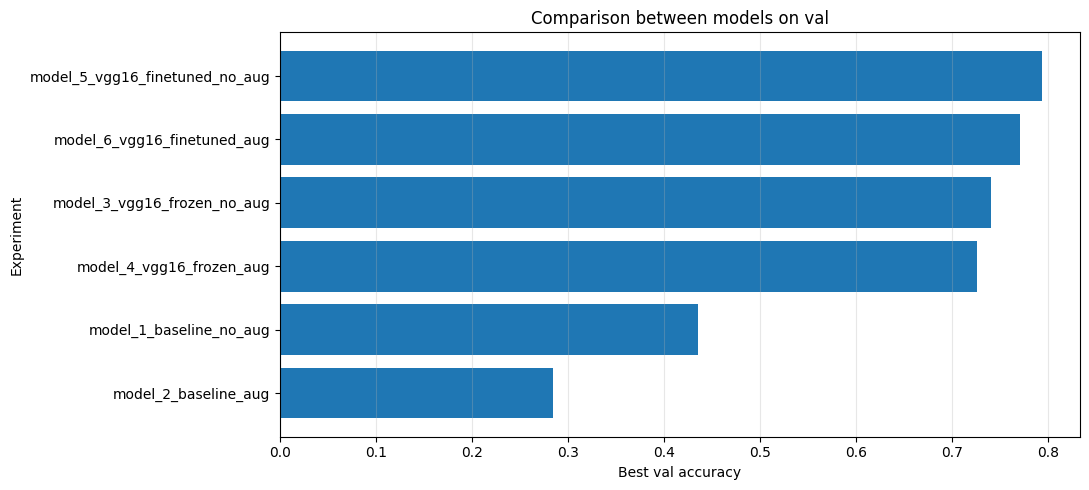

In [ ]:
plt.figure(figsize=(11, 5))
plt.barh(
  results_df["experiment"],
  results_df["best_val_accuracy"]
)
plt.xlabel("Best val accuracy")
plt.ylabel("Experiment")
plt.title("Comparison between models on val")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

Facciamo qualche considerazione:
- La baseline trae beneficio dalla data augmentation (modello 1 vs modello 2)? No, l'accuracy su val scende da 43% a 28%, forse le trasformazioni scelte per la data augmentation sono troppo aggressive. Sarebbe utile provare con qualche trasformazione in meno o comunque modificare quelle esistenti.
- La VGG16 con backbone congelato trae beneficio dalla data augmentation (modello 3 vs modello 4)? No, problema del tutto simile al caso precedente anche se la differenza qui è minima.
- Il transfer learning adottato tramite VGG16 supera la baseline (modello 1 vs modello 3 e modello 2 vs modello 4)? Assolutamente si, qui la differenza è netta con la val accuracy che raggiunge oltre li 70% grazie al transfer learning.
- Il fine-tuning migliora VGG16 senza data augmentation (modello 3 vs modello 5)? Si, ed è il caso che ci fa ottenere il miglior modello prendendo il considerazione la val accuracy raggiungendo il 79%.
- Il fine-tuning migliora VGG16 con data augmentation (modello 4 vs modello 6)? Si, anche se resta inferiore al caso precedente.

L’augmentation **non** ha migliorato nessuna delle coppie di modelli confrontabili, forse questa particolare combinazione di trasformazioni e/o intensità delle trasformazioni stesse sembra rendere il training più difficile o introdurre variazioni poco coerenti con il dataset food.

# 6 - Scelta e ottimizzazione hyperparameters

Abbiamo individuato quello che sembra il miglior modello, ovvero VGG16 con transfer learning ed il fine-tuning degli ultimi layers (senza data augmentation), cerchiamo ora di fare fine-tuning sugli hyperparameters e vedere se possiamo migliorarlo ulteriormente.

Partiamo riverificando qual'è attualmente il miglior modello:

In [ ]:
def load_model(experiment_name, device=device):
  """
  Load model from experiments registry.
  """

  info = model_registry[experiment_name]

  # Baseline
  if info["family"] == "baseline":
      model = Baseline(N_CLASSES)

  # VGG16
  elif info["family"] == "vgg16":
      model = build_vgg16(n_classes=N_CLASSES, pretrained=False)

      # ...with fine-tuning
      if info["mode"] == "fine_tuned_last_block":
          model = unfreeze_model_layers(model, start_index=info["unfreeze_start_index"])
  else:
      raise ValueError(f"Family not valid: {info['family']}")

  checkpoint = load_checkpoint_file(info["checkpoint"], map_location=device)

  model.load_state_dict(checkpoint["model_state_dict"])
  model = model.to(device)
  model.eval()

  return model, checkpoint

In [ ]:
selected_model, selected_checkpoint = load_model(best_experiment_name, device=device)

print(selected_checkpoint["experiment_name"])
print(selected_checkpoint["val_accuracy"])

model_5_vgg16_finetuned_no_aug
0.7933035714285714


Come accennato nell'introduzione ci limiteremo a cercare di ottimizzare solo alcuni degli hyperparameters come:
1. Learning rate.
2. Weight decay.
3. Dropout.
4. Scheduler.

Faremo dunque 4 esperimenti aggiuntivi, tutti costruiti a partire dal miglior modello precedentemente ottenuto.

Per fare ciò:
1. Definiamo una lista di configurazioni della rete sulla base delle ottimizzazioni degli hyperparameters che vogliamo cercare di apportare.
2. Carichiamo dinamicamente una configurazione alla volta.
3. Verifichiamo come si comporta il modello ad ogni configurazione.

In [ ]:
base_configuration = {
  "experiment_name": selected_checkpoint["experiment_name"],
  "architecture": selected_checkpoint["config"]["architecture"],
  "augmentation": selected_checkpoint["config"]["augmentation"],
  "training_mode": selected_checkpoint["config"]["training_mode"],
  "source_experiment": selected_checkpoint["experiment_name"],
  "optimizer_name": "AdamW",
  "feature_lr": selected_checkpoint["config"]["feature_learning_rate"],
  "head_lr": selected_checkpoint["config"]["head_learning_rate"],
  "weight_decay": selected_checkpoint["config"]["weight_decay"],
  "dropout": 0.30,
  "unfreeze_start_index": selected_checkpoint["config"]["unfreeze_start_index"],
  "scheduler_name": "ReduceLROnPlateau",
  "scheduler_factor": 0.5,
  "scheduler_patience": 1,
  "n_epochs": N_EPOCHS,
  "patience": PATIENCE
}

configurations = [
  {
    "experiment_name": "t1_lower_lr",
    "optimizer_name": "AdamW",
    "feature_lr": 5e-6,
    "head_lr": 5e-5,
    "weight_decay": 1e-4,
    "dropout": 0.30,
    "unfreeze_start_index": 24
  },
  {
    "experiment_name": "t2_higher_head_lr",
    "optimizer_name": "AdamW",
    "feature_lr": 1e-5,
    "head_lr": 2e-4,
    "weight_decay": 1e-4,
    "dropout": 0.30,
    "unfreeze_start_index": 24
  },
  {
    "experiment_name": "t3_more_weight_decay",
    "optimizer_name": "AdamW",
    "feature_lr": 1e-5,
    "head_lr": 1e-4,
    "weight_decay": 1e-3,
    "dropout": 0.30,
    "unfreeze_start_index": 24
  },
  {
    "experiment_name": "t4_more_dropout",
    "optimizer_name": "AdamW",
    "feature_lr": 1e-5,
    "head_lr": 1e-4,
    "weight_decay": 1e-4,
    "dropout": 0.50,
    "unfreeze_start_index": 24
  }
]

Definiamo alcune funzioni helper che ci aiuteranno ad apportare le modifiche agli hyperparameters richieste dalle configurazioni, tra cui la funzione `run_hyperparameter_experiment` che eseguirà gli esperimenti:

In [ ]:
def set_classifier_dropout(model, p=0.30):
  """
  Set classifier dropout layers.
  """

  model.classifier[2] = nn.Dropout(p=p)
  model.classifier[5] = nn.Dropout(p=p)

  return model

In [ ]:
def configure_finetuning(model, unfreeze_start_index=24, train_classifier_all=False):
  """
  Configure model for fine-tuning.
  """

  for param in model.features.parameters():
    param.requires_grad = False

  for layer in model.features[unfreeze_start_index:]:
    for param in layer.parameters():
      param.requires_grad = True

  if train_classifier_all:
    for param in model.classifier.parameters():
      param.requires_grad = True
  else:
    for param in model.classifier.parameters():
      param.requires_grad = False
    for param in model.classifier[6].parameters():
      param.requires_grad = True

  return model

In [ ]:
def build_optimizer(model, cfg):
  """
  Build AdamW optimizer.
  """

  # 1. Feature extraction learning rate
  # 2. Classifier learning rate

  feature_params = [
    p for p in model.features.parameters()
    if p.requires_grad
  ]
  head_params = [
    p for p in model.classifier.parameters()
    if p.requires_grad
  ]

  if cfg["optimizer_name"] == "AdamW":
    optimizer = torch.optim.AdamW(
      [
        {"params": feature_params, "lr": cfg["feature_lr"]},
        {"params": head_params, "lr": cfg["head_lr"]}
      ],
      weight_decay=cfg["weight_decay"]
    )

  else:
    raise ValueError(f"Optimizer not supported: {cfg['optimizer_name']}")

  return optimizer

In [ ]:
def build_scheduler(optimizer, cfg):
  """
  Build scheduler.
  """

  if cfg.get("scheduler_name", "ReduceLROnPlateau") == "ReduceLROnPlateau":
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
      optimizer,
      mode="min",
      factor=cfg.get("scheduler_factor", 0.5),
      patience=cfg.get("scheduler_patience", 1)
    )

  return None

In [ ]:
def run_hyperparameter_experiment(
  base_experiment_name,
  cfg,
  train_loader,
  val_loader,
  device
):
  """
  Run hyperparameter experiment.
  """

  source_checkpoint_path = model_registry[base_experiment_name]["checkpoint"]
  source_checkpoint = load_checkpoint_file(source_checkpoint_path, map_location=device)

  model = build_vgg16(n_classes=N_CLASSES, pretrained=False, dropout=cfg["dropout"])

  model.load_state_dict(source_checkpoint["model_state_dict"], strict=False)
  model = set_classifier_dropout(model, p=cfg["dropout"])
  model = configure_finetuning(
    model,
    unfreeze_start_index=cfg["unfreeze_start_index"],
    train_classifier_all=cfg.get("train_classifier_all", False)
  )
  model = model.to(device)

  optimizer = build_optimizer(model, cfg)
  scheduler = build_scheduler(optimizer, cfg)
  loss_function = nn.CrossEntropyLoss()

  experiment_config = {
    "architecture": "VGG16",
    "augmentation": False,
    "training_mode": "finetune_hyperparameter",
    "source_experiment": base_experiment_name,
    "optimizer_name": cfg["optimizer_name"],
    "feature_lr": cfg["feature_lr"],
    "head_lr": cfg["head_lr"],
    "weight_decay": cfg["weight_decay"],
    "dropout": cfg["dropout"],
    "unfreeze_start_index": cfg["unfreeze_start_index"],
    "train_classifier_all": cfg.get("train_classifier_all", False)
  }

  model, history, summary = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    device=device,
    experiment_name=cfg["experiment_name"],
    config=experiment_config,
    num_epochs=base_configuration["n_epochs"],
    patience=base_configuration["patience"],
    scheduler=scheduler
  )

  register_experiment(
    summary,
    {
      "family": "vgg16",
      "mode": "fine_tuned_hyperparameter_search",
      "checkpoint": summary["checkpoint"],
      "augmentation": False,
      "unfreeze_start_index": cfg["unfreeze_start_index"]
    }
  )

  return model, history, summary

**NOTA**: Ho fatto un po' di pasticci riscrivendo sempre a mano i nomi delle proprietà, prossima volta sarebbe meglio utilizzare delle costanti o meglio ancora direttamente una classe!

Eseguiamo gli esperimenti:


Experiment: t1_lower_lr
[t1_lower_lr] Epoch 01/5 | train loss 0.1873 | train acc 0.9390 | val loss 0.6975 | val acc 0.7902 | lr 5.00e-06
[t1_lower_lr] Epoch 02/5 | train loss 0.1679 | train acc 0.9437 | val loss 0.6817 | val acc 0.7964 | lr 5.00e-06
[t1_lower_lr] Epoch 03/5 | train loss 0.1399 | train acc 0.9554 | val loss 0.6958 | val acc 0.7964 | lr 5.00e-06
[t1_lower_lr] Epoch 04/5 | train loss 0.1237 | train acc 0.9596 | val loss 0.7043 | val acc 0.8027 | lr 5.00e-06
[t1_lower_lr] Epoch 05/5 | train loss 0.1161 | train acc 0.9636 | val loss 0.7051 | val acc 0.7996 | lr 2.50e-06
Early stopping at epoch:5.


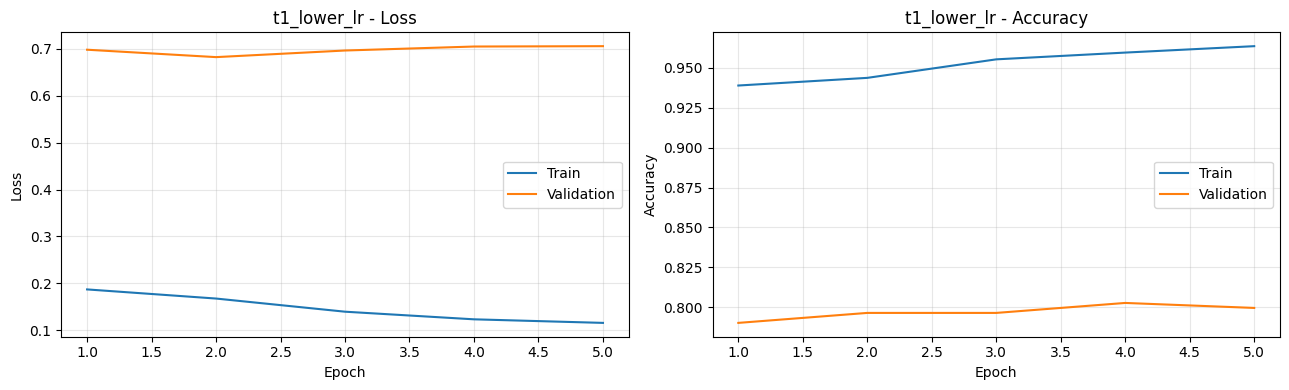


Experiment: t2_higher_head_lr
[t2_higher_head_lr] Epoch 01/5 | train loss 0.1839 | train acc 0.9396 | val loss 0.7112 | val acc 0.7915 | lr 1.00e-05
[t2_higher_head_lr] Epoch 02/5 | train loss 0.1393 | train acc 0.9545 | val loss 0.7271 | val acc 0.7933 | lr 1.00e-05
[t2_higher_head_lr] Epoch 03/5 | train loss 0.1067 | train acc 0.9665 | val loss 0.7685 | val acc 0.7946 | lr 1.00e-05
[t2_higher_head_lr] Epoch 04/5 | train loss 0.0873 | train acc 0.9724 | val loss 0.7511 | val acc 0.8027 | lr 5.00e-06
Early stopping at epoch:4.


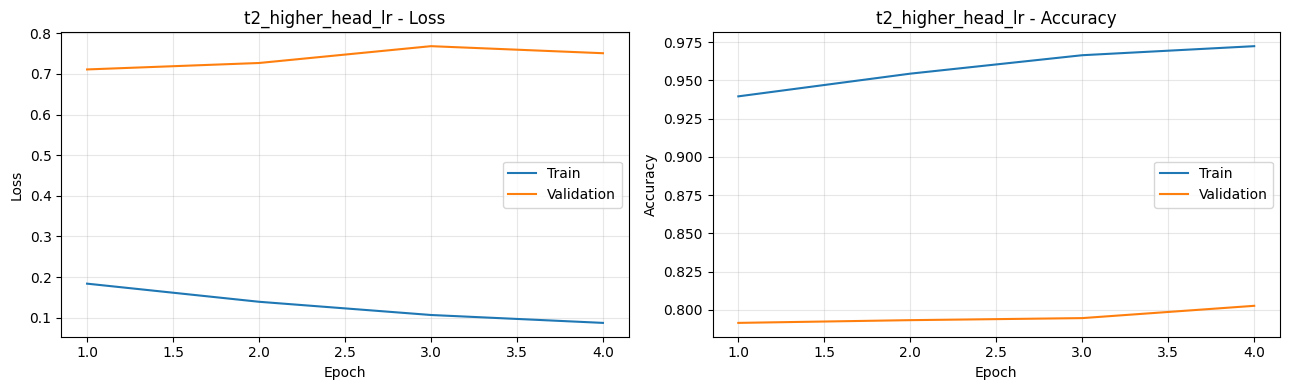


Experiment: t3_more_weight_decay
[t3_more_weight_decay] Epoch 01/5 | train loss 0.1930 | train acc 0.9374 | val loss 0.7038 | val acc 0.7893 | lr 1.00e-05
[t3_more_weight_decay] Epoch 02/5 | train loss 0.1441 | train acc 0.9529 | val loss 0.7111 | val acc 0.8004 | lr 1.00e-05
[t3_more_weight_decay] Epoch 03/5 | train loss 0.1185 | train acc 0.9634 | val loss 0.7066 | val acc 0.8013 | lr 1.00e-05
[t3_more_weight_decay] Epoch 04/5 | train loss 0.0915 | train acc 0.9723 | val loss 0.7063 | val acc 0.7987 | lr 5.00e-06
Early stopping at epoch:4.


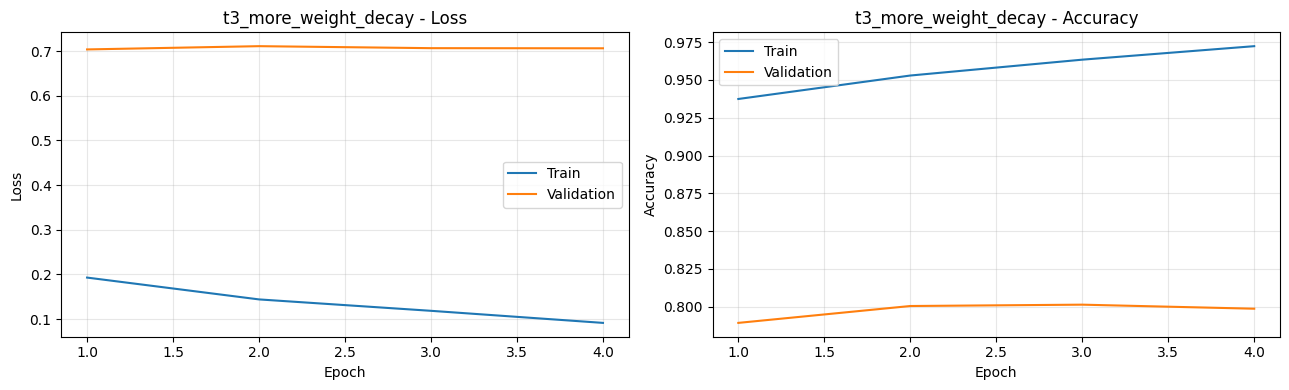


Experiment: t4_more_dropout
[t4_more_dropout] Epoch 01/5 | train loss 0.2662 | train acc 0.9116 | val loss 0.6683 | val acc 0.7906 | lr 1.00e-05
[t4_more_dropout] Epoch 02/5 | train loss 0.2186 | train acc 0.9299 | val loss 0.6549 | val acc 0.7991 | lr 1.00e-05
[t4_more_dropout] Epoch 03/5 | train loss 0.2006 | train acc 0.9339 | val loss 0.6700 | val acc 0.8013 | lr 1.00e-05
[t4_more_dropout] Epoch 04/5 | train loss 0.1711 | train acc 0.9420 | val loss 0.6808 | val acc 0.8049 | lr 1.00e-05
[t4_more_dropout] Epoch 05/5 | train loss 0.1455 | train acc 0.9518 | val loss 0.6609 | val acc 0.8116 | lr 5.00e-06
Early stopping at epoch:5.


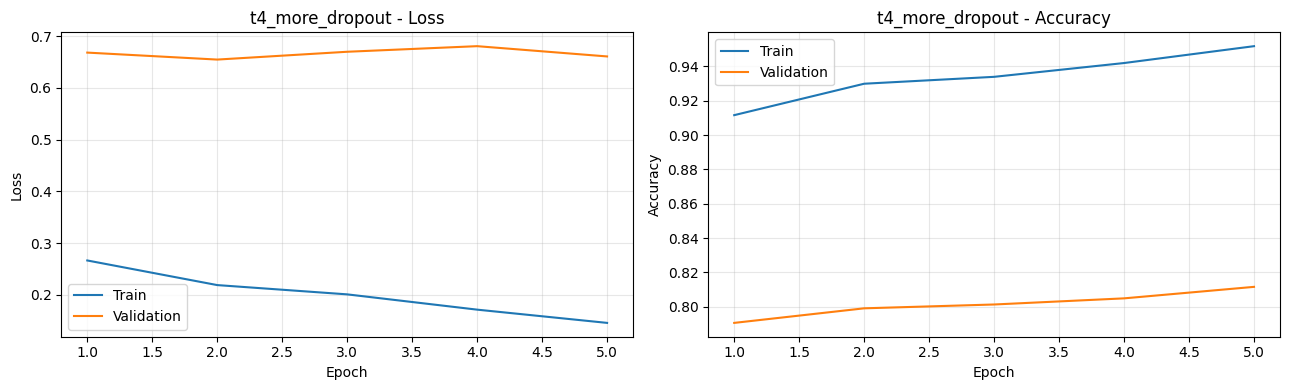

In [ ]:
tuning_summaries = []

for cfg in configurations:

  print("\n" + "=" * 80)
  print(f"Experiment: {cfg['experiment_name']}")
  print("=" * 80)

  model, history, summary = run_hyperparameter_experiment(
    base_experiment_name=selected_checkpoint["experiment_name"],
    cfg=cfg,
    train_loader=train_loader_no_aug,
    val_loader=val_loader,
    device=device
  )

  tuning_summaries.append(summary)
  plot_history(history, cfg["experiment_name"])

  del model
  gc.collect()

  empty_cuda_cache()

Verifichiamo e salviamo i risultati finali:

In [ ]:
tuning_results_df = (
  pd.DataFrame(tuning_summaries)
  .sort_values(["best_val_accuracy", "best_val_loss"], ascending=[False, True])
  .reset_index(drop=True)
)

tuning_results_df

,experiment,architecture,augmentation,training_mode,total_params,trainable_params,epochs_run,best_epoch,best_val_loss,best_val_accuracy,checkpoint
0,t4_more_dropout,VGG16,False,finetune_hyperparameter,134317902,7136782,5,2,0.654853,0.799107,./content/checkpoints/t4_more_dropout.pth
1,t1_lower_lr,VGG16,False,finetune_hyperparameter,134317902,7136782,5,2,0.681749,0.796429,./content/checkpoints/t1_lower_lr.pth
2,t2_higher_head_lr,VGG16,False,finetune_hyperparameter,134317902,7136782,4,1,0.711193,0.791518,./content/checkpoints/t2_higher_head_lr.pth
3,t3_more_weight_decay,VGG16,False,finetune_hyperparameter,134317902,7136782,4,1,0.703804,0.789286,./content/checkpoints/t3_more_weight_decay.pth


In [ ]:
tuning_results_df.to_csv(os.path.join(RESULTS_DIR, "hyperparameter_tuning_results.csv"), index=False)

best_tuning_experiment = tuning_results_df.iloc[0]["experiment"]
print("Best experiment with hyperparameters optimization:", best_tuning_experiment)

Best experiment with hyperparameters optimization: t4_more_dropout


Confronto con il miglior modello precedente:

In [ ]:
previous_best_df = pd.DataFrame(experiment_results)
previous_best_row = previous_best_df[previous_best_df["experiment"] == "model_5_vgg16_finetuned_no_aug"].copy()

comparison_df = pd.concat([
  previous_best_row,
  tuning_results_df.head(3),
], axis=0).reset_index(drop=True)

comparison_df[[
  "experiment",
  "training_mode",
  "trainable_params",
  "best_epoch",
  "best_val_loss",
  "best_val_accuracy"
]]

,experiment,training_mode,trainable_params,best_epoch,best_val_loss,best_val_accuracy
0,model_5_vgg16_finetuned_no_aug,fine_tune_last_block,7136782,2,0.680981,0.793304
1,t4_more_dropout,finetune_hyperparameter,7136782,2,0.654853,0.799107
2,t1_lower_lr,finetune_hyperparameter,7136782,2,0.681749,0.796429
3,t2_higher_head_lr,finetune_hyperparameter,7136782,1,0.711193,0.791518


Notiamo che l'ottimizzazione più efficace è stata quella di aumentare il dropout, ovvero una regolarizzazione più forte.

`t4_more_dropout` è il nuovo miglior modello con la val accuracy più alta (80,40%) e la val loss più bassa (0,65) e rispetto al precedente modello migliore aumenta l’accuracy di 1,07 punti percentuali e riduce la loss di circa 4,24 punti percentuali.

In [ ]:
best_overall = tuning_results_df.iloc[0]["experiment"]
selected_checkpoint = model_registry[best_overall]["checkpoint"]

selection_summary = pd.DataFrame([
  {
    "selected_experiment": best_overall,
    "checkpoint": selected_checkpoint
  }
])

selection_summary.to_csv(os.path.join(RESULTS_DIR, "selected_model_after_tuning.csv"), index=False)
print(selection_summary)

  selected_experiment                                 checkpoint
0     t4_more_dropout  ./content/checkpoints/t4_more_dropout.pth


# 7 - Valutazione finale e analisi risultati

Passiamo alla valutazione del miglior modello ottenuto sul test set:

In [ ]:
selected_checkpoint

'./content/checkpoints/t4_more_dropout.pth'

In [ ]:
checkpoint = load_checkpoint_file(selected_checkpoint, map_location=device)
checkpoint_config = checkpoint["config"]

checkpoint_config

{'architecture': 'VGG16',
 'augmentation': False,
 'training_mode': 'finetune_hyperparameter',
 'source_experiment': 'model_5_vgg16_finetuned_no_aug',
 'optimizer_name': 'AdamW',
 'feature_lr': 1e-05,
 'head_lr': 0.0001,
 'weight_decay': 0.0001,
 'dropout': 0.5,
 'unfreeze_start_index': 24,
 'train_classifier_all': False}

In [ ]:
final_dropout = checkpoint_config["dropout"]

final_model = build_vgg16(
  n_classes=N_CLASSES,
  pretrained=False,
  dropout=final_dropout
)

final_model.load_state_dict(checkpoint["model_state_dict"])
final_model = final_model.to(device)

print("Experiment:", checkpoint["experiment_name"])

Experiment: t4_more_dropout


In [ ]:
@torch.inference_mode()

def predict_test_set(model, dataloader, device):
  """
  Perform model's prediction on test set.
  """

  y_true, y_pred, confidences = [], [], []

  model.eval()

  for images, labels in dataloader:

    images = images.to(device, non_blocking=True)
    logits = model(images)

    probabilities = torch.softmax(logits, dim=1)
    confidence, predictions = probabilities.max(dim=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predictions.cpu().numpy())
    confidences.extend(confidence.cpu().numpy())

  return np.array(y_true), np.array(y_pred), np.array(confidences)

Calcoliamo le metriche:

In [ ]:
y_test, y_pred, confidence = predict_test_set(final_model, test_loader, device)

test_accuracy = accuracy_score(y_test, y_pred)
precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(y_test, y_pred, average="macro", zero_division=0)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(y_test, y_pred, average="weighted", zero_division=0)

final_metrics = pd.DataFrame([{
  "selected_experiment": checkpoint["experiment_name"],
  "test_accuracy": test_accuracy,
  "precision_macro": precision_macro,
  "recall_macro": recall_macro,
  "f1_macro": f1_macro,
  "f1_weighted": f1_weighted
}])

final_metrics.round(4)
final_metrics

,selected_experiment,test_accuracy,precision_macro,recall_macro,f1_macro,f1_weighted
0,t4_more_dropout,0.800357,0.801845,0.800357,0.800176,0.800176


Calcoliamo la confusion matrix:

In [ ]:
report_dict = classification_report(
  y_test,
  y_pred,
  target_names=CLASS_NAMES,
  output_dict=True,
  zero_division=0
)

class_report_df = pd.DataFrame(report_dict).T
class_report_df.round(3)
class_report_df

,precision,recall,f1-score,support
cheesecake,0.804762,0.845000,0.824390,200.000000
omelette,0.859375,0.825000,0.841837,200.000000
Fries,0.883495,0.910000,0.896552,200.000000
apple_pie,0.871795,0.850000,0.860759,200.000000
Crispy Chicken,0.794595,0.735000,0.763636,200.000000
Hot Dog,0.827957,0.770000,0.797927,200.000000
Taquito,0.686813,0.625000,0.654450,200.000000
Donut,0.675000,0.810000,0.736364,200.000000
Baked Potato,0.732323,0.725000,0.728643,200.000000
ice_cream,0.810680,0.835000,0.822660,200.000000


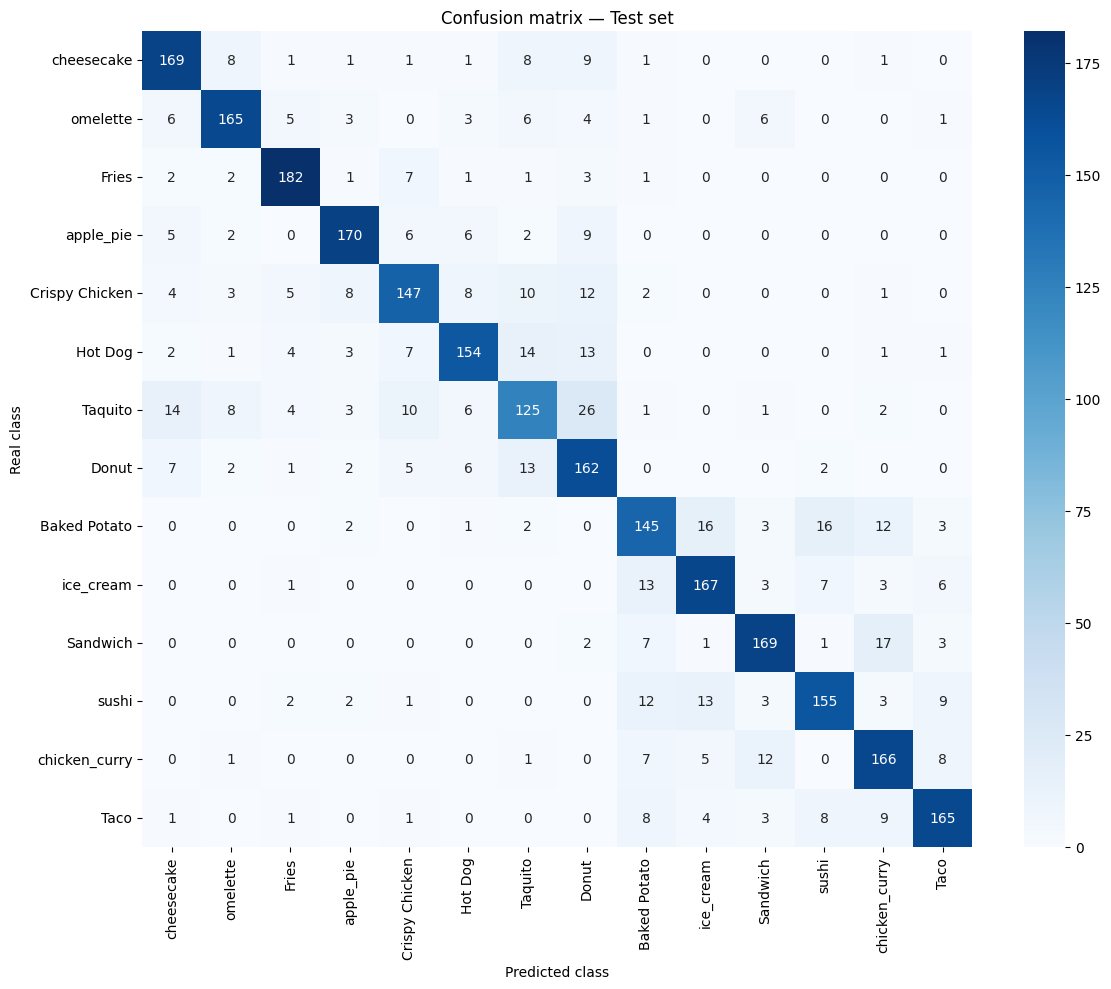

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
  cm,
  annot=True,
  fmt="d",
  cmap="Blues",
  xticklabels=CLASS_NAMES,
  yticklabels=CLASS_NAMES
)
plt.xlabel("Predicted class")
plt.ylabel("Real class")
plt.title("Confusion matrix — Test set")
plt.tight_layout()
plt.show()

Abbiamo buona capacità di generalizzazione su tutte le 14 classi, ciascuna rappresentata da 200 immagini del test set.

Le prestazioni migliori si osservano sulla classe **Crispy Chicken** (F1=0,892), **cheesecake** (0,848), **Donut** (0,840) e **Hot Dog** (0,837). Le classi più difficili sono invece **sushi** (F1=0,677), **Baked Potato** (0,753) e **chicken_curry** (0,767), probabilmente perché presentano maggiore variabilità visiva o caratteristiche condivise con altri tipi di cibi.

Nel complesso, il transfer learning con VGG16 e un fine-tuning controllato si è dimostrato chiaramente più efficace della CNN baseline, mentre l’aumento del dropout ha contribuito a migliorare la robustezza del classificatore.